<h1 style="text-align:center">Muon Scattering Angle Analysis for MCS </h1>

<p style="text-align:center"> Analyzing muon scattering angle distributions using gaussians and double-gaussian functions to study effectivess of MCS energy estimation.</p>

<p style="text-align:center"> NOTICE: Open this notebook using likelihoodpid venv.</p>

# 1. import and open files

In [1]:
import os
import re

from multiprocessing import Pool, cpu_count
from scipy import stats
from tqdm.auto import tqdm

import ROOT
from ROOT import TMath, TF1, TCanvas, TFormula
from ROOT import gROOT, gObjectTable
from array import array
#import uproot
import pandas as pd
import numpy as np
import sbnd_style_copy as sbnd

import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import LogNorm
from matplotlib import ticker
from matplotlib.ticker import (AutoMinorLocator, MultipleLocator)
from matplotlib import gridspec
from matplotlib import lines as mlines

import pickle

from scipy.interpolate import CubicSpline
from scipy import stats
from scipy import integrate
import math
    

/home/sungbino/py/likelihoodpid/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
version = "v10_14_02_02"

In [3]:
input_file1 = "/home/xpuig/cafpyana/mcs_df_test.df" #original test df
input_file2 = "/home/xpuig/mcs_df_gen2_mc_part.df" #test file, aka input_file3 with less statistics
input_file3 = "/home/xpuig/mcs_mc_aurora_merged-copy.df"

print("keys")
#splh.print_keys(input_file)

keys


# 2. Using PyROOT to graph a Gaussian and Double Gaussian

In [4]:
# Read the muon trajectory dataframe

muon_df = pd.read_hdf(input_file1, key="muon_traj_0")
muon_gen2test = pd.read_hdf(input_file2, key="muon_traj_0")
muon_gen2 = pd.read_hdf(input_file3, key="muon_traj_0")

#Finding energies at each breakpoint
muonEnergies = []
momenta = muon_gen2["resranges_mid_mean_P"]
bp = 0
mu_mass = .1057 #GeV/c^2
mu_mass_MeV = 105.7
numRows = momenta.shape[0]
plist = []
eType = []
while bp < numRows:
    p = momenta.values[bp]
    plist.append(p)
    E = (((p**2.)+(mu_mass**2.))**0.5) # E^2 = p^2c^2+(mc^2)^2 (Energy-momentum formula). c=1, so E = sqrt(p^2+m^2)
    Efloat = E.item()
    muonEnergies.append(Efloat)
    
    bp += 1

muon_gen2
#print(max(muonEnergies))

dtheta  \
__ntuple entry rec.slc..index rec.slc.reco.pfp..index breakpoint               
9        20    0              0                       0             8.126597   
                                                      1            16.431035   
                                                      2            39.033117   
                                                      3            64.198350   
                                                      4            35.336421   
...                                                                      ...   
2984     3153  0              0                       0             7.522182   
                                                      1            86.612781   
                                                      2           143.695885   
                                                      3           135.622916   
                                                      4           125.217154   

                                                                   dtheta_xz  \
__ntuple entry rec.slc..index rec.slc.reco.pfp..index breakpoint               
9        20    0              0                       0             8.432704   
                                                      1             8.350455   
                                                      2           -43.891164   
                                                      3           -56.994999   
                                                      4           -32.852276   
...                                                                      ...   
2984     3153  0              0                       0           -19.334392   
                                                      1           -73.884834   
                                                      2           -18.249194   
                                                      3          -100.735104   
                                                      4            33.257251   

                                                                   dtheta_yz  \
__ntuple entry rec.slc..index rec.slc.reco.pfp..index breakpoint               
9        20    0              0                       0            -1.385466   
                                                      1           -12.938441   
                                                      2            -0.777621   
                                                      3           -69.206492   
                                                      4           -38.984165   
...                                                                      ...   
2984     3153  0              0                       0            -1.758556   
                                                      1            32.290646   
                                                      2            86.871115   
                                                      3            28.941366   
                                                      4           112.525362   

                                                                  angle_xz_rot  \
__ntuple entry rec.slc..index rec.slc.reco.pfp..index breakpoint                 
9        20    0              0                       0              -2.650254   
                                                      1             -13.350419   
                                                      2               6.276448   
                                                      3             -52.943668   
                                                      4             -29.252728   
...                                                                        ...   
2984     3153  0              0                       0              -3.777975   
                                                      1               4.753395   
                                                      2              22.966428   
                                             

In [5]:
def th1_from_series(series, name=r"$d\theta_{xz}$", title="dQ/dx;dQ/dx [A.U./cm];Counts",
                    nbins=100, xmin=-250.0, xmax=250.0, weights=None, edges=None):
    # drop NaNs
    vals = series.to_numpy(dtype=float)
    vals = vals[~np.isnan(vals)]
    if weights is not None:
        w = np.asarray(weights, dtype=float)
        w = w[~np.isnan(series.to_numpy())]
    else:
        w = None

    # binning
    if edges is None:
        edges = np.linspace(xmin, xmax, nbins + 1)
    else:
        edges = np.asarray(edges, dtype=float)
        nbins = len(edges) - 1

    # histogram with numpy
    counts, edges = np.histogram(vals, bins=edges, weights=w)

    # make TH1 with variable binning
    h = ROOT.TH1F(name, title, nbins, array('d', edges))
    h.Sumw2()
    for i, c in enumerate(counts, start=1):
        h.SetBinContent(i, float(c))
        # Set sqrt(N) if unweighted; else keep Sumw2 weights
        if w is None:
            h.SetBinError(i, np.sqrt(c))
    return h

In [6]:
ROOT.gInterpreter.Declare(r"""
#include "TMath.h"
double gaus_cpp(double *x, double *p) {
  const double A = p[0];
  const double mu = p[1];
  const double sig = p[2];

  if (sig <= 0) return 0.0;

  return A*exp(-0.5*(pow(((x[0]-mu)/sig),2)));
} 

double double_gaus_cpp(double *x, double *p) {
  return gaus_cpp(x, p) + gaus_cpp(x, p+3); 
}  
                          
double double_gaus_norm(double *x, double *p) {
  const double scale = p[0];
  const double A = p[1];
  const double mu1 = p[2];
  const double sig1 = p[3];
  const double mu2 = p[4];
  const double sig2 = p[5];

  return scale*A*exp(-0.5*(pow(((x[0]-mu1)/sig1),2)))+scale*(1-A)*exp(-0.5*(pow(((x[0]-mu2)/sig2),2)));                                                
}                                                              
""")

True

<h2 style="text-align: center">Single Gaussian</h2>

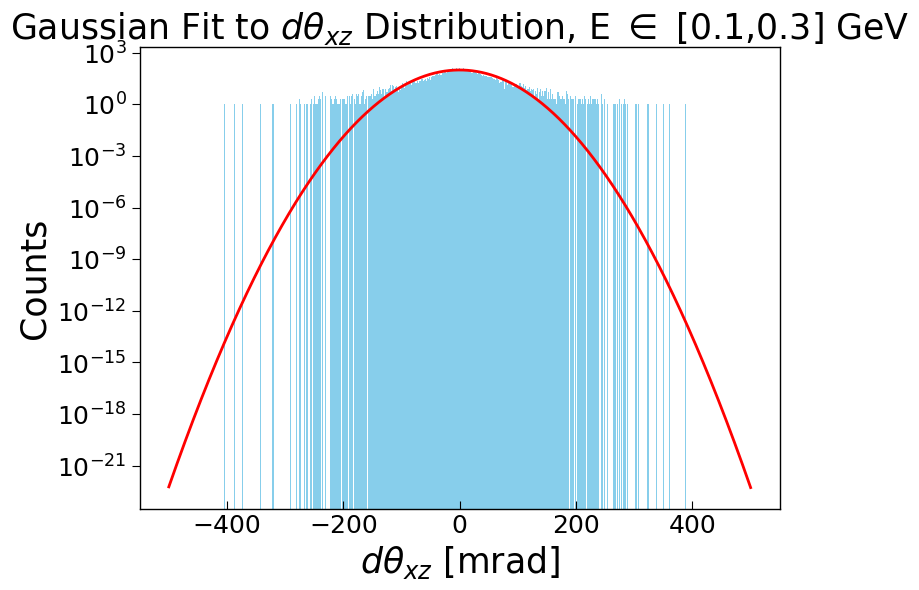

****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      2269.77
NDf                       =           97
Edm                       =  5.44091e-09
NCalls                    =          163
p0                        =      840.258   +/-   9.96059     
p1                        =    -0.221718   +/-   0.33525     
p2                        =      47.3319   +/-   0.449781    


Info in <TCanvas::MakeDefCanvas>:  created default TCanvas with name c1


In [7]:
def gaus_fit(df, column, energyBounds = [0.1,0.3], name="gaus",nbins=1000):
    series = df[column]
    e1 = energyBounds[0]
    e2 = energyBounds[1]
    counter = 0
    energyNew = []
    dataNew = []
    #Performing a cut on the muon energies and dtheta_xz to only include those within the specified energy bin
    while counter < len(series):
        if muonEnergies[counter] > e1 and muonEnergies[counter] < e2:
            dataNew.append(series.values[counter])
            energyNew.append(muonEnergies[counter])
        counter += 1
    seriesNew = pd.Series(dataNew)

    func1 = TF1('func1', ROOT.gaus_cpp, -500, 500, 3) #Create gaussian function with 3 parameters
    func1.SetParameters(0.78, 0.452, 95)
    h_dtheta_xz = th1_from_series(seriesNew, name=name) #Making TH1 Object to fit to the data


    h_dtheta_xz.Fit(func1, "S") #Fitting the gaussian function to the data
    area,mu,sigma = func1.GetParameter(0), func1.GetParameter(1), func1.GetParameter(2) #Getting the parameters of the fitted gaussian function

    bin_heights, bin_borders, _ = plt.hist(seriesNew, bins=nbins, range=(-500, 500), label='Fitted Gaussian', color='skyblue',log=True)
    norm = len(seriesNew) * (bin_borders[1] - bin_borders[0])

    x = np.linspace(-500, 500, nbins)
    pdf = stats.norm.pdf(x, mu, sigma) * norm #Probability Density Function

    
    plt.plot(x, pdf, color='red', linewidth=2, label='Fitted Gaussian')
    plt.xlabel(r"$d\theta_{xz}$ [mrad]")
    plt.ylabel("Counts")
    plt.title(r"Gaussian Fit to $d\theta_{xz}$ Distribution, E $\in$ ["+ str(e1) + "," + str(e2) + "] GeV")

    plt.show()

    return [area, mu, sigma]

core_params =gaus_fit(muon_df, 'dtheta_xz', energyBounds=[0.1, 0.3], name=r"$d\theta_{xz}$", nbins=2000)

<h2 style='text-align: center'>Double Gaussian Fitting<h2>

Integral of histogram:  22892.0


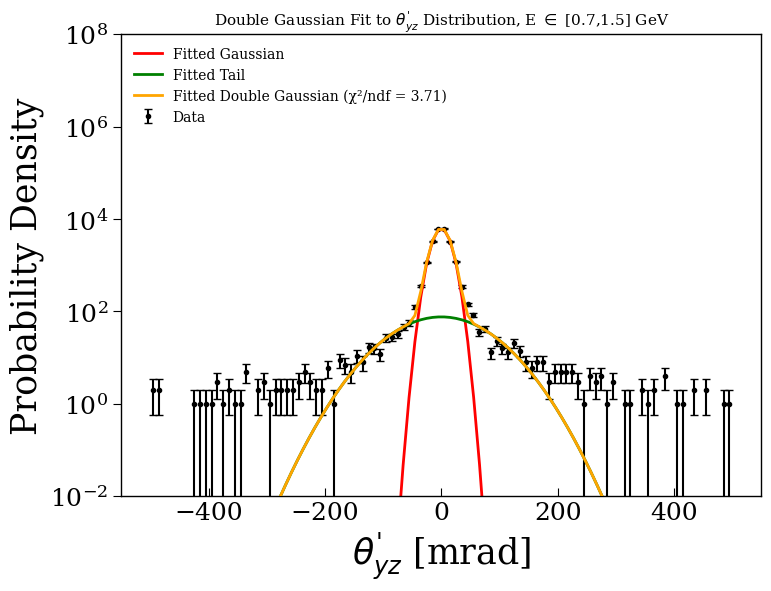

fraction           0.988007
mu                 0.036014
sigma             13.524659
mu_tail           -0.099999
sigma_tail        65.396063
fraction_err       0.001361
mu_err             0.148722
sigma_err          0.095683
mu_tail_err        0.128361
sigma_tail_err     3.947851
dtype: float64

****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =       296.54
NDf                       =           80
Edm                       =  7.63602e-07
NCalls                    =          939
p0                        =      6371.97   +/-   58.2614      	 (limited)
p1                        =     0.988007   +/-   0.00136092   	 (limited)
p2                        =    0.0360142   +/-   0.148722     	 (limited)
p3                        =      13.5247   +/-   0.0956831    	 (limited)
p4                        =   -0.0999994   +/-   0.128361     	 (limited)
p5                        =      65.3961   +/-   3.94785      	 (limited)


Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 


In [8]:
def double_gaus_fit_5param(df,column,energyBounds=[],xrange=[-500,500],name="",core=False,tail=False,nbins=1000):
    plt.rc('font', family='serif', size=12)
    series = df[column]
    e1 = energyBounds[0]
    e2 = energyBounds[1]
    xmin, xmax = xrange[0], xrange[1]
    counter = 0
    energyNew = []
    dataNew = []
    #Performing a cut on the muon energies and dtheta_xz to only include those within the specified energy bin
    while counter < len(series):
        if muonEnergies[counter] >= e1 and muonEnergies[counter] <= e2:
            dataNew.append(series.values[counter])
            energyNew.append(muonEnergies[counter])
        counter += 1
    seriesNew = pd.Series(dataNew)

    func1 = TF1('func1', ROOT.double_gaus_norm, xmin, xmax, 6) #Create double gaussian function with 6 parameters, *Make a limit on params
    #func1.SetParameters(410., 0.452, 70., 0.4972, 300.5) #[0.1,0.3 init]
    func1.SetParameters(10000.,0.02,0.,1000.,0.,14100.)
    #func1.SetParameters(420., 0.98, 0., 70., 0., 400.5)  
    # fit range for scaling factor
    func1.SetParLimits(0, 0., 28000.)
    # fit ranges for area fraction 
    func1.SetParLimits(1, 0.5, 1.) #or try .5

    # fit ranges for sigma
    func1.SetParLimits(3, 0., 5000.)
    func1.SetParLimits(5, 0.,25500.)

    #fit ranges for mu
    func1.SetParLimits(2, -0.1, 0.1)
    func1.SetParLimits(4, -0.1, 0.1)

    h_dtheta_xz = th1_from_series(seriesNew, name=name, nbins=nbins, xmin=xmin, xmax=xmax) #Making TH1 Object to fit to the data
    #h_dtheta_xz.Scale(1./ h_dtheta_xz.Integral())
    print("Integral of histogram: ", h_dtheta_xz.Integral())
    h_dtheta_xz.Fit(func1, "S") #Fitting the double gaussian function to the data
   
    mu,sigma = func1.GetParameter(2), func1.GetParameter(3) #Getting the parameters of the fitted double gaussian function
    mu_tail,sigma_tail = func1.GetParameter(4), func1.GetParameter(5) #Getting the parameters of the fitted double gaussian function
    fraction,scale = func1.GetParameter(1), func1.GetParameter(0) #Getting the parameters of the fitted double gaussian function
    #Get Parameter Errors

    mu_err,sigma_err = func1.GetParError(2), func1.GetParError(3)
    mu_tail_err,sigma_tail_err = func1.GetParError(4), func1.GetParError(5)
    scale_err,fraction_err = func1.GetParError(0), func1.GetParError(1)

    #Getting fit results (chi squared, ndf)
    chi2 = func1.GetChisquare()
    ndf = func1.GetNDF()
    chi2_ndf = chi2/ndf

    bin_heights, bin_borders = np.histogram(seriesNew, bins=nbins, range=(xmin, xmax)) #Normalizing histogram to 1
    bin_centers = (bin_borders[:-1] + bin_borders[1:]) / 2
    plt.errorbar(bin_centers, bin_heights, yerr=np.sqrt(bin_heights), fmt='o', color='black', gapcolor='purple', label='Data',markersize=3, capsize=3, linewidth=1.5, zorder=1)

    plt.yscale('log')

    x = np.linspace(xmin, xmax, nbins)
    pdf = scale *fraction * np.exp(-0.5 * ((x - mu) / sigma) ** 2) #Probability for core gaus
    pdf_tail = scale*(1-fraction) * np.exp(-0.5 * ((x - mu_tail) / sigma_tail) ** 2) #Probability for tail gaus
    double_pdf = pdf + pdf_tail
    
    if core: plt.plot(x, pdf, color='red', linewidth=2, label='Fitted Gaussian',zorder=2)
    if tail: plt.plot(x, pdf_tail, color='green', linewidth=2, label='Fitted Tail',zorder=3)
    plt.plot(x, double_pdf, color='orange', linewidth=2, label=f'Fitted Double Gaussian (χ²/ndf = {round(chi2_ndf,2)})', zorder=4)

    #change y axis 1000 more to fit legends
    plt.legend(loc='upper left', fontsize=10)
    plt.ylim(0.01,100000000)

    plt.xlabel(f"{name} [mrad]")
    plt.ylabel("Probability Density")
    plt.title(r"Double Gaussian Fit to " +name+ r" Distribution, E $\in$ ["+ str(e1) + "," + str(e2) + "] GeV",size=11)
    #plt.tight_layout()

    plt.show()

    fitResult = pd.Series([fraction, mu, sigma, mu_tail, sigma_tail, fraction_err,mu_err, sigma_err, mu_tail_err, sigma_tail_err],index=['fraction', 'mu', 'sigma', 'mu_tail', 'sigma_tail', 'fraction_err', 'mu_err', 'sigma_err', 'mu_tail_err', 'sigma_tail_err'])

    return fitResult

dgaus_fitResult = double_gaus_fit_5param(muon_gen2, 'dtheta_yz_prime', xrange=[-500,500], energyBounds=[0.7, 1.5], name=r"$\theta_{yz}^'$",nbins=100,core=True,tail=True)
dgaus_fitResult    

# 3. Double Gaussian Subplots

In [10]:
## This function takes user input. Updating code block below to take in a mutable array instead of user input.
def double_gaus_subplots_v1(df,column,energyBounds=[0.1,0.9],xname="",core=False,tail=False,nbins=1000):
    series = df[column]
    dgaus_parameters = pd.DataFrame()
    eb1 = energyBounds[0]
    eb2 = energyBounds[1]
    #print(eb2)
    eStep = 0.1
    energyBins = []
    energy = eb1
    while energy < eb2:
        energyBins.append(round(energy, 2))
        energy += eStep
    #energyBins.append(eb2)
    print(energyBins)
    counter = 0
    energyNew = []
    dataNew = []
    #Performing a cut on the muon energies and dtheta_xz to only include those within the specified energy bin
    while counter < len(series):
        if muonEnergies[counter] > eb1 and muonEnergies[counter] < eb2:
            dataNew.append(series.values[counter])
            energyNew.append(muonEnergies[counter])
        counter += 1
    seriesNew = pd.Series(dataNew)

    print(len(energyBins)-1)
    
    fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(25, 20),sharey=True)
    axs = axs.flatten()

    #parameters=[420.,0.98,0.,70.,0,300.5] -> Good init parameters for [0.1-0.3] GeV
    df_list = []
    for i in range(len(energyBins)-1):
        count = 0
        e1 = energyBins[i]
        e2 = energyBins[i+1]
        listNew2 = []
        parameterStr = input(f"Type your desired initial parameters for [{e1}-{e2}] GeV"+"\n"+"Make sure they're in the following order, each separated by a comma:"+"\n"+"Scale factor,Area fraction,mu1,sigma1,mu2,sigma2.")
        params = parameterStr.split(",")
        for j in range(len(params)):
            params[j] = float(params[j])
        #print(params)
        while count < len(seriesNew):
            if energyNew[count] >= e1 and energyNew[count] <= e2:
                listNew2.append(seriesNew[count])
            count += 1
        seriesNew2 = pd.Series(listNew2)
     
        func = TF1('func', ROOT.double_gaus_norm, -500, 500, 6) #Create double gaussian function with 6 parameters, *Make a limit on params
        func.SetParameters(params[0],params[1],params[2],params[3],params[4],params[5]) 
     
        #[0.1,0.3 init]
        #func1.SetParameters(420.,0.02,0.,70.,0,300.5) #0.02 area fraction works as opposed to 0.98- so I suppose this param is for the tail gaus.
    
        # fit range for scaling factor
        func.SetParLimits(0, 0., 1000.)
        # fit range for area fraction 
        func.SetParLimits(1, 0., 1.) #or try .5

        # fit ranges for sigma1, sigma2
        func.SetParLimits(3, 0., 420.)
        func.SetParLimits(5, 0., 600.)

        #fit ranges for mu1, mu2
        func.SetParLimits(2, -20., 20.)
        func.SetParLimits(4, -20., 20.)

        #func1.setparlimits(3, 0.0, seriesNew.max()) #tail amplitude limit, make max the max y in histogram
        h_dtheta_xz = th1_from_series(seriesNew2, name='roothist', nbins=nbins, xmin=-500, xmax=500) #Making TH1 Object to fit to the data
        #h_dtheta_xz.Scale(1./ h_dtheta_xz.Integral())
        print("Integral of histogram: ", h_dtheta_xz.Integral())
        h_dtheta_xz.Fit(func, "S") #Fitting the double gaussian function to the data
   
        mu,sigma = func.GetParameter(2), func.GetParameter(3) #Getting the parameters of the fitted double gaussian function
        mu_tail,sigma_tail = func.GetParameter(4), func.GetParameter(5) #Getting the parameters of the fitted double gaussian function
        fraction,scale = func.GetParameter(1), func.GetParameter(0) #Getting the parameters of the fitted double gaussian function
        #Get Parameter Errors

        mu_err,sigma_err = func.GetParError(2), func.GetParError(3)
        mu_tail_err,sigma_tail_err = func.GetParError(4), func.GetParError(5)
        scale_err,fraction_err = func.GetParError(0), func.GetParError(1)

        #Getting fit results (chi squared, ndf)
        chi2 = func.GetChisquare()
        ndf = func.GetNDF()
        chi2_ndf = chi2/ndf

        bin_heights, bin_borders = np.histogram(seriesNew2, bins=nbins, range=(-500, 500)) #Normalizing histogram to 1
        bin_centers = (bin_borders[:-1] + bin_borders[1:]) / 2

        plt.yscale('log')

        x = np.linspace(-500, 500, nbins)
        pdf = scale *fraction * np.exp(-0.5 * ((x - mu) / sigma) ** 2) #Probability for core gaus
        pdf_tail = scale*(1-fraction) * np.exp(-0.5 * ((x - mu_tail) / sigma_tail) ** 2) #Probability for tail gaus
        double_pdf = pdf + pdf_tail
        
        x = np.linspace(-500, 500, nbins)
        pdf = scale * fraction * np.exp(-0.5 * ((x - mu) / sigma) ** 2) #Probability for core gaus
        pdf_tail = scale * (1 - fraction) * np.exp(-0.5 * ((x - mu_tail) / sigma_tail) ** 2) #Probability for tail gaus
        double_pdf = pdf + pdf_tail
        
        axs[i].errorbar(bin_centers, bin_heights, yerr=np.sqrt(bin_heights), fmt='o', color='black', label='Data',markersize=5, capsize=3, linewidth=1.5, zorder=1)
        axs[i].set_yscale('log')
        if core: axs[i].plot(x, pdf, color='red', linewidth=2, label='Fitted Gaussian',zorder=2)
        if tail: axs[i].plot(x, pdf_tail, color='green', linewidth=2, label='Fitted Tail',zorder=3)
        axs[i].plot(x, double_pdf, color='orange', linewidth=2, label=f'Fitted Double Gaussian \n'+r'$\chi^2$/NDf'+f"={round(chi2,2)}/{ndf}", zorder=4)
        axs[i].set_title(r"Local $KE_{\mu} \, \in$ "+f"[{e1}-{e2}] GeV")
        axs[i].set_xlabel(xname, loc='right')
        axs[i].legend(loc='upper left', fontsize=10)

        ser = pd.Series([fraction,mu,sigma,mu_tail,sigma_tail,fraction_err,mu_err,sigma_err,mu_tail_err,sigma_tail_err],index=['fraction','mu','sigma','mu_tail','sigma_tail','fraction_err','mu_err','sigma_err','mu_tail_err','sigma_tail_err'])
        df2 = pd.DataFrame({f"KE in [{e1}-{e2}]": ser})
        df_list.append(df2)

    #create dataframe with resulting fit parameters
    xvarCol = pd.Series([np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan],index=['fraction','mu','sigma','mu_tail','sigma_tail','fraction_err','mu_err','sigma_err','mu_tail_err','sigma_tail_err']) #divider for each var
    xvarDf = pd.DataFrame({column:xvarCol})
    df_list.insert(0,xvarDf)
    dgaus_parameters = pd.concat(df_list,axis=1)

    
    #change y axis 1000 more to fit legends
    #axs[0].legend(loc='upper left', fontsize=10)
    axs[0].set_ylim(0.00000001,10000)
    fig.text(0.08, 0.5, 'Probability Density', va='center', rotation='vertical',size='xx-large')
    plt.tight_layout
    plt.show()

    return dgaus_parameters

In [10]:
# Currently working on ''stage zero'', which is calculating the resolution sigmas

def double_gaus_subplots(df,column,energyBounds=[0.1,0.9],maxBin=[0.7,1.5],eStep=0.1,initParams=[],xranges=[[-400,400]],xname="",core=False,tail=False,nbins=1000):
    series = df[column]

    # grabbing max energy bin defined by user to then grab mean energy for caluclating sigma_res1
    maxEnergyBin = []
    while item < len(series):
        if muonEnergies[counter] >= maxBin[0] and muonEnergies[counter] < maxBin[1]:
            maxEnergyBin.append(muonEnergies[counter])
        item += 1
    ser_maxEnergyBin = pd.Series(maxEnergyBin)
    E_mean = ser_maxEnergyBin.mean()
    sig_H = 13.6/(E_mean*(1-((mu_mass_MeV**2)/(E_mean**2)))) #sigma_H we will use to calculate resolution sigma 1 and 2

   #loops through each stage of the iterative tuning procedure for each fit parameter in the (sig_1, A, sig_2) 
    '''
    for i in range(2):
        if i == 0:
            print("Hello world!")
    '''

    #dgaus_parameters = pd.DataFrame()
    eb1 = energyBounds[0]
    eb2 = energyBounds[1]
    fit_xmin, fit_xmax = -500, 500 #to use for plots, linspace, and fits. xmin and xmax are for cosmetic purposes
    #print(eb2)
    #eStep = 0.1
    energyBins = []
    energy = eb1
    while energy < eb2:
        energyBins.append(round(energy, 2))
        energy += eStep
    #energyBins.append(eb2)
    print(energyBins)
    counter = 0
    energyNew = []
    dataNew = []
    #Performing a cut on the muon energies and dtheta_xz to only include those within the specified energy bin
    while counter < len(series):
        if muonEnergies[counter] > eb1 and muonEnergies[counter] < eb2:
            dataNew.append(series.values[counter])
            energyNew.append(muonEnergies[counter])
        counter += 1
    seriesNew = pd.Series(dataNew)

    print(len(energyBins)-1)
    
    fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(25, 20),sharey=True)
    axs = axs.flatten()

    #parameters=[420.,0.98,0.,70.,0,300.5] -> Good init parameters for [0.1-0.3] GeV
    df_list = []
    for i in range(len(energyBins)-1):
        if len(xranges) > 1: xrange = xranges[i]
        else: xrange = xranges[0]
        xmin = xrange[0]
        xmax = xrange[1]
        count = 0
        initSubList = initParams[i]
        e1 = energyBins[i]
        e2 = energyBins[i+1]
        listNew2 = []
        #parameterStr = input(f"Type your desired initial parameters for [{e1}-{e2}] GeV"+"\n"+"Make sure they're in the following order, each separated by a comma:"+"\n"+"Scale factor,Area fraction,mu1,sigma1,mu2,sigma2.")
        #params = parameterStr.split(",")
        #for j in range(len(params)):
        #    params[j] = float(params[j])
        #print(params)
        while count < len(seriesNew):
            if energyNew[count] >= e1 and energyNew[count] <= e2:
                listNew2.append(seriesNew[count])
            count += 1
        seriesNew2 = pd.Series(listNew2)
     
        func = TF1('func', ROOT.double_gaus_norm, fit_xmin, fit_xmax, 6) #Create double gaussian function with 6 parameters, *Make a limit on params
        func.SetParameters(initSubList[0],initSubList[1],initSubList[2],initSubList[3],initSubList[4],initSubList[5]) 
     
        #[0.1,0.3 init]
        #func1.SetParameters(420.,0.02,0.,70.,0,300.5) #0.02 area fraction works as opposed to 0.98- so I suppose this param is for the tail gaus.
    
        # fit range for scaling factor
        func.SetParLimits(0, 0., 1000.)
        # fit range for area fraction 
        func.SetParLimits(1, 0., 1.) #or try .5

        # fit ranges for sigma1, sigma2
        func.SetParLimits(3, 0., 520.)
        func.SetParLimits(5, 0., 600.)

        #fit ranges for mu1, mu2
        func.SetParLimits(2, -20., 20.)
        func.SetParLimits(4, -20., 20.)

        #func1.setparlimits(3, 0.0, seriesNew.max()) #tail amplitude limit, make max the max y in histogram
        h_dtheta_xz = th1_from_series(seriesNew2, name='roothist', nbins=nbins, xmin=fit_xmin, xmax=fit_xmax) #Making TH1 Object to fit to the data
        #h_dtheta_xz.Scale(1./ h_dtheta_xz.Integral())
        print("Integral of histogram: ", h_dtheta_xz.Integral())
        h_dtheta_xz.Fit(func, "S") #Fitting the double gaussian function to the data
   
        mu,sigma = func.GetParameter(2), func.GetParameter(3) #Getting the parameters of the fitted double gaussian function
        mu_tail,sigma_tail = func.GetParameter(4), func.GetParameter(5) #Getting the parameters of the fitted double gaussian function
        fraction,scale = func.GetParameter(1), func.GetParameter(0) #Getting the parameters of the fitted double gaussian function
        #Get Parameter Errors

        mu_err,sigma_err = func.GetParError(2), func.GetParError(3)
        mu_tail_err,sigma_tail_err = func.GetParError(4), func.GetParError(5)
        scale_err,fraction_err = func.GetParError(0), func.GetParError(1)

        #Getting fit results (chi squared, ndf)
        chi2 = func.GetChisquare()
        ndf = func.GetNDF()
        chi2_ndf = chi2/ndf

        bin_heights, bin_borders = np.histogram(seriesNew2, bins=nbins, range=(fit_xmin, fit_xmax)) #Normalizing histogram to 1
        bin_centers = (bin_borders[:-1] + bin_borders[1:]) / 2

        plt.yscale('log')

        x = np.linspace(fit_xmin, fit_xmax, nbins)
        pdf = scale *fraction * np.exp(-0.5 * ((x - mu) / sigma) ** 2) #Probability for core gaus
        pdf_tail = scale*(1-fraction) * np.exp(-0.5 * ((x - mu_tail) / sigma_tail) ** 2) #Probability for tail gaus
        double_pdf = pdf + pdf_tail
        
        axs[i].errorbar(bin_centers, bin_heights, yerr=np.sqrt(bin_heights), fmt='', color='blue', alpha=0.3, label='Error',markersize=2, capsize=3, linewidth=0.5, zorder=1)
        axs[i].scatter(x,bin_heights,color='black',label='Data',s=10)
        axs[i].set_yscale('log')
        if core: axs[i].plot(x, pdf, color='red', linewidth=2, label='Fitted Gaussian',zorder=2)
        if tail: axs[i].plot(x, pdf_tail, color='green', linewidth=2, label='Fitted Tail',zorder=3)
        axs[i].plot(x, double_pdf, color='orange', linewidth=2, label=f'Fitted Double Gaussian \n'+r'$\chi^2$/NDf'+f"={round(chi2,2)}/{ndf}", zorder=4)
        axs[i].set_title(r"Local $KE_{\mu} \, \in$ "+f"[{e1}-{e2}] GeV")
        axs[i].set_xlabel(xname, loc='right')
        axs[i].legend(loc='upper left', fontsize=10)
        axs[i].set_xlim(xmin,xmax)

        ser = pd.Series([fraction,mu,sigma,mu_tail,sigma_tail,fraction_err,mu_err,sigma_err,mu_tail_err,sigma_tail_err],index=['fraction','mu','sigma','mu_tail','sigma_tail','fraction_err','mu_err','sigma_err','mu_tail_err','sigma_tail_err'])
        df2 = pd.DataFrame({f"KE in [{e1}-{e2}]": ser})
        df_list.append(df2)

    #create dataframe with resulting fit parameters
    xvarCol = pd.Series([np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan],index=['fraction','mu','sigma','mu_tail','sigma_tail','fraction_err','mu_err','sigma_err','mu_tail_err','sigma_tail_err']) #divider for each var
    xvarDf = pd.DataFrame({column:xvarCol})
    df_list.insert(0,xvarDf)
    dgaus_parameters = pd.concat(df_list,axis=1)

    
    #change y axis 1000 more to fit legends
    #axs[0].legend(loc='upper left', fontsize=10)
    axs[0].set_ylim(0.00000001,10000)
    fig.text(0.08, 0.5, 'Probability Density', va='center', rotation='vertical',size='xx-large')
    plt.tight_layout
    plt.show()

    return dgaus_parameters


yzPrime_initParams = [[150.,0.02,0.,60.,0.,600.5],[150.,0.02,0.,60.,0.,600.5],[150.,0.02,0.,60.,0.,600.5],[150.,0.02,0.,60.,0.,600.5],[150.,0.02,0.,60.,0.,600.5],[150.,0.02,0.,60.,0.,600.5],[150.,0.02,0.,60.,0.,600.5],[150.,0.02,0.,60.,0.,600.5]]
yzPrime_xranges = [[-500,500],[-500,500],[-500,500],[-700,700],[-500,500],[-500,500],[-500,500],[-100,100]]

xzPrime_initParams = [[250.,0.02,0.,20.,0.,1500.5],[250.,0.02,0.,100.,0.,900.5],[250.,0.02,0.,100.,0.,900.5],[250.,0.02,0.,20.,0.,1500.5],[250.,0.02,0.,20.,0.,2500.5],[250.,0.02,0.,20.,0.,1500.5],[250.,0.02,0.,20.,0.,1500.5],[250.,0.02,0.,20.,0.,1500.5]]
xzPrime_xranges = [[-500,500],[-400,400],[-350,350],[-350,350],[-250,250],[-250,250],[-100,100],[-60,60]]

dgaus_fitResults_xzp = double_gaus_subplots(muon_gen2, 'dtheta_xz_prime', initParams=xzPrime_initParams,xname=r"$\theta_{XZ}^'$ [mrad]",energyBounds=[0.1, 0.9], nbins=1000, xranges=xzPrime_xranges, core=True)
dgaus_fitResults_yzp = double_gaus_subplots(muon_gen2, 'dtheta_yz_prime', initParams=yzPrime_initParams, xname=r"$\theta_{YZ}^'$ [mrad]",energyBounds=[0.1, 0.9], nbins=1000, xranges=yzPrime_xranges, core=True)
df_list = [dgaus_fitResults_xzp,dgaus_fitResults_yzp]
fitResults = pd.concat(df_list,axis=1)
fitResults

UnboundLocalError: cannot access local variable 'item' where it is not associated with a value

In [ ]:
'''
def double_gaus_stageZero(df,column,energyBounds=[0.1,0.9], sigma_res1_list = [], sigma_res2_list = [],maxBin=[0.7,1.5],eStep=0.1,initParams=[],xranges=[[-400,400]],xname="",core=False,tail=False,nbins=1000):
    series = df[column]
    sig_res_df = pd.DataFrame({'Tune':[np.nan],'Column 2':[np.nan],'Column 3':[np.nan]})
    sig_res_list = ['0',1.,2.]
    # grabbing max energy bin defined by user to then grab mean energy for caluclating sigma_res1
    maxEnergyBin = []
    newData = []
    item = 0
    abs_vx_list = []
    while item < len(series):
        if muonEnergies[item] >= maxBin[0] and muonEnergies[item] < maxBin[1]:
            newData.append(series.values[item])
            maxEnergyBin.append(muonEnergies[item])
            if df["v_x_seg0"].values[item] < 0: abs_vx_list.append(abs(df["v_x_seg0"].values[item]))
            else: abs_vx_list.append(df["v_x_seg0"].values[item])
        item += 1
    ser_maxEnergyBin = pd.Series(maxEnergyBin)
    newSeries = pd.Series(newData)
    E_mean = ser_maxEnergyBin.mean()
    sig_H = 13.6/(E_mean*(1-((mu_mass_MeV**2)/(E_mean**2)))) #sigma_H we will use to calculate resolution sigma 1 and 2

   #loops through each stage of the iterative tuning procedure for each fit parameter in the following order: (sig_res1+2, sig_1, A, sig_2) 
 
    fit_xmin, fit_xmax = -500, 500 #to use for plots, linspace, and fits. xmin and xmax are for cosmetic purposes
    initSubList = initParams[-1]
    '''
    Separate into |v_x| bins- skip this for dtheta_xz_prime
    '''
    if column=='dtheta_yz_prime':
        
        vx_bins = [0.,0.1,0.2,0.35,0.75,1.]
        count = 0
        
        while count < len(vx_bins)-1:
            left_vx = vx_bins[count]
            right_vx = vx_bins[count+1]
            newDataList = []
            count2 = 0
            while count2 < len(abs_vx_list)-1:
                if abs_vx_list[count2] > left_vx and abs_vx_list[count2] < right_vx:
                    newDataList.append(newSeries.values[count2])
                count2 += 1
            count += 1
            vxBinSeries = pd.Series(newDataList)

            func = TF1('func', ROOT.double_gaus_norm, fit_xmin, fit_xmax, 6) #Create double gaussian function with 6 parameters, *Make a limit on params
            func.SetParameters(initSubList[0],initSubList[1],initSubList[2],initSubList[3],initSubList[4],initSubList[5]) 

            # fit range for scaling factor
            func.SetParLimits(0, 0., 1000.)
            # fit range for area fraction 
            func.SetParLimits(1, 0.5, 1.) #or try .5

            # fit ranges for sigma1, sigma2
            func.SetParLimits(3, 0., 520.)
            func.SetParLimits(5, 0., 600.)

            #fit ranges for mu1, mu2
            func.SetParLimits(2, -20., 20.)
            func.SetParLimits(4, -20., 20.)

            #func1.setparlimits(3, 0.0, seriesNew.max()) #tail amplitude limit, make max the max y in histogram
            h_dtheta_xz = th1_from_series(vxBinSeries, name='roothist', nbins=nbins, xmin=fit_xmin, xmax=fit_xmax) #Making TH1 Object to fit to the data
            #h_dtheta_xz.Scale(1./ h_dtheta_xz.Integral())
            #print("Integral of histogram: ", h_dtheta_xz.Integral())
            h_dtheta_xz.Fit(func, "S") #Fitting the double gaussian function to the data

            sigma_1_0 = func.GetParameter(3) #Getting sigma_1_0 to calculate sigma_res1 and to fit later
            sigma_2_0 = func.GetParameter(5)

            sig_res1 = ((sigma_1_0**2)-((2/3)*(sig_H**2)))**0.5
            sig_res2 = ((sigma_2_0**2)-((2/3)*(sig_H**2)))**0.5

            sig_res_list[0] = (f'dtheta_yz_prime, |v_x| in [{left_vx}-{right_vx}]')
            sig_res_list[1] = sig_res1
            sig_res_list[2] = sig_res2  

            sig_res_series = pd.Series(sig_res_list)

            pd.concat([sig_res_df, sig_res_series], axis = 0)
        #else: print("ERROR: We lost some values of vx when calculating their abs values...")
    else:
        sig_res_list.append('dtheta_xz_prime')
        func = TF1('func', ROOT.double_gaus_norm, fit_xmin, fit_xmax, 6) #Create double gaussian function with 6 parameters, *Make a limit on params
        func.SetParameters(initSubList[0],initSubList[1],initSubList[2],initSubList[3],initSubList[4],initSubList[5]) 

        # fit range for scaling factor
        func.SetParLimits(0, 0., 1000.)
        # fit range for area fraction 
        func.SetParLimits(1, 0.5, 1.) #or try .5

        # fit ranges for sigma1, sigma2
        func.SetParLimits(3, 0., 520.)
        func.SetParLimits(5, 0., 600.)

        #fit ranges for mu1, mu2
        func.SetParLimits(2, -20., 20.)
        func.SetParLimits(4, -20., 20.)

        #func1.setparlimits(3, 0.0, seriesNew.max()) #tail amplitude limit, make max the max y in histogram
        h_dtheta_xz = th1_from_series(newSeries, name='roothist', nbins=nbins, xmin=fit_xmin, xmax=fit_xmax) #Making TH1 Object to fit to the data
        #h_dtheta_xz.Scale(1./ h_dtheta_xz.Integral())
        #print("Integral of histogram: ", h_dtheta_xz.Integral())
        h_dtheta_xz.Fit(func, "S") #Fitting the double gaussian function to the data

        sigma_1_0 = func.GetParameter(3) #Getting sigma_1_0 to calculate sigma_res1 and to fit later
        sigma_2_0 = func.GetParameter(5)

        sig_res1 = ((sigma_1_0**2)-((2/3)*(sig_H**2)))**0.5
        sig_res2 = ((sigma_2_0**2)-((2/3)*(sig_H**2)))**0.5

        sig_res_list.append(sig_res1)
        sig_res_list.append(sig_res2)
        sig_res_series = pd.Series(sig_res_list)

        pd.concat([sig_res_df, sig_res_series], axis = 0)
 
    return sig_res_df #switch over to a list with each sig_res now that we are implementing |vx| binning for dtheta_yz_prime
'''

In [9]:
def fit_sigma_res(series, sig_H, initSubList, fit_xmin=-500, fit_xmax=500, nbins=1000, rebin=None, sigLims=None):
    """Fit a double-gaussian to `series` and return (sig_res1, sig_res2)."""

    func = TF1('func', ROOT.double_gaus_norm, fit_xmin, fit_xmax, 6)
    func.SetParameters(*initSubList[:6])

    #fit range for scale factor
    func.SetParLimits(0, 0., 1500.)
    # fit range for area fraction 
    func.SetParLimits(1, 0.5, 1.) #or try .5

    # fit ranges for sigma
    if sigLims==None:
        func.SetParLimits(3, 0., 40.)
        func.SetParLimits(5, 0.,150.)
    else:
        func.SetParLimits(3, sigLims[0], sigLims[1])
        func.SetParLimits(5, sigLims[0], sigLims[1])

    #fit ranges for mu
    func.SetParLimits(2, -0.1, 0.1)
    func.SetParLimits(4, -0.1, 0.1)

    hist = th1_from_series(series, name='roothist', nbins=nbins, xmin=fit_xmin, xmax=fit_xmax)
    numBins1 = hist.GetNbinsX()

    #th1_max = hist.GetMaximum()
    if rebin is not None: 
        hist.Rebin(rebin)
        numBins2 = hist.GetNbinsX()


    #hist.Scale(1/hist.Integral())

    hist.Fit(func, "S")

    sigma_1_0, sigma_1_0_err = func.GetParameter(3), func.GetParError(3)
    sigma_2_0, sigma_2_0_err = func.GetParameter(5), func.GetParError(5)

    scale, frac, mu_1_0, mu_2_0 = func.GetParameter(0), func.GetParameter(1), func.GetParameter(2), func.GetParameter(4)
    frac_err, mu_1_0_err, mu_2_0_err = func.GetParError(1), func.GetParError(2), func.GetParError(4)

    chi2 = func.GetChisquare()
    ndf = func.GetNDF()
    chi2_ndf = chi2/ndf

    fitParams, fitParErrors, score = [scale,frac,mu_1_0,sigma_1_0,mu_2_0,sigma_2_0], [frac_err,mu_1_0_err,sigma_1_0_err,mu_2_0_err,sigma_2_0_err], [chi2,ndf,chi2_ndf]

    sig_res1 = ((sigma_1_0**2) - ((2/3)*(sig_H**2)))**0.5
    sig_res2 = ((sigma_2_0**2) - ((2/3)*(sig_H**2)))**0.5

    sig_res1_err = ((sigma_1_0*sigma_1_0_err)/(((sigma_1_0**2)-(2/3)*(sig_H**2))**0.5))**0.5
    sig_res2_err = ((sigma_2_0*sigma_2_0_err)/(((sigma_2_0**2)-(2/3)*(sig_H**2))**0.5))**0.5

    if rebin is not None: return sig_res1, sig_res1_err, sig_res2, sig_res2_err, fitParams, fitParErrors, score, numBins1, numBins2
    else: return sig_res1, sig_res1_err, sig_res2, sig_res2_err, fitParams, fitParErrors, score, numBins1


def double_gaus_stageZero_v1(df, column, energyBounds=[0.1, 0.9], maxBin=[0.7, 1.5],
                           eStep=0.1, xranges=None, yranges=None, initParams=[], nbins=1000, core=True, tail=False, rebin=None):

    series = df[column]
    initSubList = initParams[-1]
    fit_xmin, fit_xmax = -500, 500

    # --- select rows in the max energy bin ---
    muonEnergies_arr = np.asarray(muonEnergies)
    mask = (muonEnergies_arr >= maxBin[0]) & (muonEnergies_arr < maxBin[1])
    newSeries = series[mask].reset_index(drop=True)
    E_mean = pd.Series(muonEnergies)[mask].mean()
    sig_H = 13.6 / (E_mean * (1 - (mu_mass_MeV**2 / E_mean**2)))
    print(r"\langle E_\mu \rangle = " + f"{E_mean} GeV.")

    rows = []

    if column == 'dtheta_yz_prime':

        fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(25, 20))
        axs = axs.flatten()

        # only this column needs |v_x| binning
        abs_vx = df.loc[mask, 'v_x_seg0'].abs().reset_index(drop=True)
        vx_bins = [0., 0.04, 0.1, 0.35, 1.]
        n_vx_bins = len(vx_bins) - 1

        # validate xranges up front so a bad input fails loudly, not silently mid-loop
        if xranges is not None and len(xranges) != n_vx_bins:
            raise ValueError(
                f"xranges has {len(xranges)} entries but there are {n_vx_bins} |v_x| bins; "
                f"pass one [xmin, xmax] pair per bin (or None to use defaults)."
            )
        if yranges is not None and len(yranges) != n_vx_bins:
            raise ValueError(
                f"yranges has {len(yranges)} entries but there are {n_vx_bins} |v_x| bins; "
                f"pass one [xmin, xmax] pair per bin (or None to use defaults)."
            )

        counter = 0
        for left, right in zip(vx_bins[:-1], vx_bins[1:]):
            initSubList = initParams[counter]
            bin_series = newSeries[(abs_vx > left) & (abs_vx < right)]
            if rebin != None: sig_res1, sig_res1_err, sig_res2, sig_res2_err, fitParams, fitParErrors, fitScore, numBins, numBins_r = fit_sigma_res(bin_series, sig_H, initSubList,
                                                fit_xmin, fit_xmax, nbins, rebin=rebin)
            else: sig_res1, sig_res2, fitParams, fitParErrors, fitScore,numBins = fit_sigma_res(bin_series, sig_H, initSubList,
                                                fit_xmin, fit_xmax, nbins)
            rows.append({
                'Tune': f'dtheta_yz_prime, |v_x| in [{left}-{right}]',
                'sig_res1': sig_res1,
                'sig_res1_err': fitParErrors[2],
                'sig_res2': sig_res2,
                'sig_res2_err': fitParErrors[4]
            })

            if rebin is not None:
                if numBins[0] == numBins[1]:
                    raise ValueError("Debug rebin function call in fit_sigma_res.")
            
            scale,frac,mu_1_0,sigma_1_0,mu_2_0,sigma_2_0 = fitParams[0], fitParams[1],fitParams[2],fitParams[3],fitParams[4],fitParams[5]
            #print(fitParams)

            if rebin is not None: bin_heights, bin_borders = np.histogram(newSeries, bins=numBins[1], range=(fit_xmin, fit_xmax))
            else: bin_heights, bin_borders = np.histogram(newSeries, bins=numBins, range=(fit_xmin, fit_xmax))
            bin_centers = (bin_borders[:-1] + bin_borders[1:]) / 2
            axs[counter].errorbar(bin_centers, bin_heights, yerr=np.sqrt(bin_heights), fmt='o', color='black', gapcolor='purple', label='Data',markersize=3, capsize=3, linewidth=1.5, zorder=1)

            axs[counter].set_yscale('log')

            if rebin is not None: x = np.linspace(fit_xmin, fit_xmax, numBins_r)
            else: x = np.linspace(fit_xmin, fit_xmax, numBins)

            pdf = scale *frac * np.exp(-0.5 * ((x - mu_1_0) / sigma_1_0) ** 2) #Probability for core gaus
            pdf_tail = scale*(1-frac) * np.exp(-0.5 * ((x - mu_2_0) / sigma_2_0) ** 2) #Probability for tail gaus
            double_pdf = pdf + pdf_tail

            if core: axs[counter].plot(x, pdf, color='red', linewidth=2, label='Fitted Gaussian',zorder=2)
            if tail: axs[counter].plot(x, pdf_tail, color='green', linewidth=2, label='Fitted Tail',zorder=3)
            axs[counter].plot(x, double_pdf, color='orange', linewidth=2, label=f'Fitted Double Gaussian', zorder=4)

            # main legend (Data / Fitted Gaussian / Fitted Tail / Fitted Double Gaussian)
            main_legend = axs[counter].legend(loc='upper left', fontsize=10)
            axs[counter].add_artist(main_legend)  # keep it — otherwise the next legend() call below replaces it

            axs[counter].set_title(r"$|\nu_{x}| \, \in$" + f" [{left}-{right}]")

            # separate, text-only legend showing this subplot's chi2/ndf
            chi2_handle = mlines.Line2D([], [], color='none',
                                         label=f'χ²/ndf = {round(fitScore[2], 2)}')
            axs[counter].legend(handles=[chi2_handle], loc='upper right', fontsize=10,
                                 frameon=True, handlelength=0, handletextpad=0)

            #if counter==0: axs[0].legend(loc='upper left', fontsize=10)
            bin_yrange = yranges[counter] if yranges is not None else None
            if bin_yrange is not None:
                axs[counter].set_ylim(bin_yrange[0], bin_yrange[1])
            else:
                axs[counter].set_ylim(0.1, 1000)

            # per-subplot x-range: use the user-supplied pair if given, else default fit range
            bin_xrange = xranges[counter] if xranges is not None else None
            if bin_xrange is not None:
                axs[counter].set_xlim(bin_xrange[0], bin_xrange[1])
            else:
                axs[counter].set_xlim(fit_xmin, fit_xmax)

            counter += 1

    else:
        # dtheta_xz_prime: single row, no vx binning
        initSubList = initParams[-1]
        if rebin is not None: sig_res1, sig_res1_err, sig_res2, sig_res2_err, fitParams, fitParErrors, fitScore, numBins, numBins_r = fit_sigma_res(newSeries, sig_H, initSubList,
                                                                                                        fit_xmin, fit_xmax, nbins, rebin=rebin)
        else: sig_res1, sig_res1_err, sig_res2, sig_res2_err, fitParams, fitParErrors, fitScore, numBins = fit_sigma_res(newSeries, sig_H, initSubList,
                                                                                    fit_xmin, fit_xmax, nbins)
        rows.append({
            'Tune': 'dtheta_xz_prime',
            'sig_res1': sig_res1,
            'sig_res1_err': fitParErrors[2],
            'sig_res2': sig_res2,
            'sig_res2_err': fitParErrors[4]
        })

        if rebin is not None:
            if numBins == numBins_r:
                raise ValueError(f"{numBins} = {numBins_r} -- number of bins in histogram does not change even after .Rebin." 
                                +" Check fit_sigma_res for bugs (likely has to do with .Rebin function.)")
        
        #print(fitParams)
        scale,frac,mu_1_0,sigma_1_0,mu_2_0,sigma_2_0 = fitParams[0], fitParams[1],fitParams[2],fitParams[3],fitParams[4],fitParams[5]

        fig, ax = plt.subplots()

        if rebin is not None: bin_heights, bin_borders = np.histogram(newSeries, bins=numBins_r, range=(fit_xmin, fit_xmax))
        else: bin_heights, bin_borders = np.histogram(newSeries, bins=numBins, range=(fit_xmin, fit_xmax))
        bin_centers = (bin_borders[:-1] + bin_borders[1:]) / 2
        ax.errorbar(bin_centers, bin_heights, yerr=np.sqrt(bin_heights), fmt='o', color='black', gapcolor='purple', label='MC Simulation',markersize=3, capsize=3, linewidth=1.5, zorder=1)

        ax.set_yscale('log')

        if rebin is not None: x = np.linspace(fit_xmin, fit_xmax, numBins_r)
        else: x = np.linspace(fit_xmin, fit_xmax, numBins)
        pdf = scale *frac * np.exp(-0.5 * ((x - mu_1_0) / sigma_1_0) ** 2) #Probability for core gaus
        pdf_tail = scale*(1-frac) * np.exp(-0.5 * ((x - mu_2_0) / sigma_2_0) ** 2) #Probability for tail gaus
        double_pdf = pdf + pdf_tail

        if core: ax.plot(x, pdf, color='red', linewidth=2, label='Fitted Core Gaussian',zorder=2)
        if tail: ax.plot(x, pdf_tail, color='green', linewidth=2, label='Fitted Tail Gaussian',zorder=3)
        ax.plot(x, double_pdf, color='orange', linewidth=2, label=f'Fitted Double Gaussian (core+tail)', zorder=4)

        ax.legend(loc='upper left', fontsize=10)
        ax.set_ylim(0.01,10000)

        xz_xrange = xranges[0]
        ax.set_xlim(xz_xrange[0], xz_xrange[1])

        # main legend (Data / Fitted Gaussian / Fitted Tail / Fitted Double Gaussian)
        main_legend = plt.legend(loc='upper left', fontsize=10)
        ax.add_artist(main_legend)  # keep it — otherwise the next legend() call below replaces it

        # separate, text-only legend showing this subplot's chi2/ndf
        chi2_handle = mlines.Line2D([], [], color='none',
                                        label=f'χ²/ndf = {round(fitScore[2], 2)}')
        ax.legend(handles=[chi2_handle], loc='upper right', fontsize=10,
                                frameon=True, handlelength=0, handletextpad=0)
        
        sbnd.sbnd_sim(ax, 0.6, 0.87, fontsize=20)
        
        ax.set_xlabel(r"$\theta_{xz}^{'}$ [mrad]")
        ax.set_ylabel(r'Probability Density')
        ax.set_title(r"$\theta_{xz}^{'}$ Distribution for $\langle E_{\mu} \rangle \in$ " + f'[{maxBin[0]},{maxBin[1]}] GeV', size=20)

    plt.show()

    return pd.DataFrame(rows, columns=['Tune', 'sig_res1', 'sig_res1_err','sig_res2', 'sig_res2_err'])

In [10]:
def double_gaus_stageZero_v2(df, column, energyBounds=[0.1, 0.9], maxBin=[0.7, 1.5], sigLims=None,
                           eStep=0.1, xranges=None, yranges=None, initParams=[], nbins=1000, fitRange=None, errdf=False, core=True, tail=False, rebin=None):

    series = df[column]
    initSubList = initParams[-1]

    if fitRange == None: 
        fit_xmin, fit_xmax = -500, 500
    else: fit_xmin, fit_xmax = fitRange[0], fitRange[1]
 

    # --- select rows in the max energy bin ---
    muonEnergies_arr = np.asarray(muonEnergies)
    mask = (muonEnergies_arr >= maxBin[0]) & (muonEnergies_arr < maxBin[1])
    newSeries = series[mask].reset_index(drop=True)
    E_mean = pd.Series(muonEnergies)[mask].mean()
    sig_H = 13.6 / (E_mean * (1 - ((mu_mass_MeV**2) / (E_mean**2))))
    print(f"sig_H: {sig_H}")

    rows = []

    if column == 'dtheta_yz_prime':

        fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(25, 20))
        axs = axs.flatten()

        # only this column needs |v_x| binning
        abs_vx = df.loc[mask, 'v_x_seg0'].abs().reset_index(drop=True)
        vx_bins = [0., 0.04, 0.1, 0.35, 1.]
        n_vx_bins = len(vx_bins) - 1

        # validate xranges up front so a bad input fails loudly, not silently mid-loop
        if xranges is not None and len(xranges) != n_vx_bins:
            raise ValueError(
                f"xranges has {len(xranges)} entries but there are {n_vx_bins} |v_x| bins; "
                f"pass one [xmin, xmax] pair per bin (or None to use defaults)."
            )
        if yranges is not None and len(yranges) != n_vx_bins:
            raise ValueError(
                f"yranges has {len(yranges)} entries but there are {n_vx_bins} |v_x| bins; "
                f"pass one [xmin, xmax] pair per bin (or None to use defaults)."
            )

        counter = 0
        for left, right in zip(vx_bins[:-1], vx_bins[1:]):
            initSubList = initParams[counter]
            currentRange_fit = fitRange[counter]
            fit_xmin, fit_xmax = currentRange_fit[0], currentRange_fit[1]
            bin_series = newSeries[(abs_vx > left) & (abs_vx < right)]
            if rebin is not None: sig_res1, sig_res1_err, sig_res2, sig_res2_err, fitParams, fitParErrors, fitScore, numBins, numBins_r = fit_sigma_res(bin_series, sig_H, initSubList,
                                                fit_xmin, fit_xmax, nbins, rebin=rebin,sigLims=sigLims)
            else: sig_res1, sig_res1_err, sig_res2, sig_res2_err, fitParams, fitParErrors, fitScore, numBins = fit_sigma_res(bin_series, sig_H, initSubList,
                                                fit_xmin, fit_xmax, nbins,sigLims=sigLims)
            if errdf:
                rows.append({
                    'Tune': f'dtheta_yz_prime, |v_x| in [{left},{right}]',
                    'sig_res1': round(sig_res1,2),
                    'sig_res1_err': round(sig_res1_err,2),
                    'sig_res2': round(sig_res2,2),
                    'sig_res2_err': round(sig_res2_err,2)
                })
            else:
                rows.append({
                    'Tune': f'dtheta_yz_prime, |v_x| in [{left},{right}]',
                    'sig_res1': f'{round(sig_res1,2)} ± {round(sig_res1_err,2)}',
                    'sig_res2': f'{round(sig_res2,2)} ± {round(sig_res2_err,2)}',
                })

            if rebin is not None:
                if numBins_r==numBins:
                    raise ValueError(f"{numBins} = {numBins_r} -- number of bins in histogram does not change even after .Rebin." 
                                        +" Check fit_sigma_res for bugs (likely has to do with .Rebin function.)")
            
            scale,frac,mu_1_0,sigma_1_0,mu_2_0,sigma_2_0 = fitParams[0], fitParams[1],fitParams[2],fitParams[3],fitParams[4],fitParams[5]
            #print(fitParams)

            if rebin is not None: bin_heights, bin_borders = np.histogram(bin_series, bins=numBins_r, range=(fit_xmin, fit_xmax))
            else: bin_heights, bin_borders = np.histogram(newSeries, bins=numBins, range=(fit_xmin, fit_xmax))
            bin_centers = (bin_borders[:-1] + bin_borders[1:]) / 2
            axs[counter].errorbar(bin_centers, bin_heights, yerr=np.sqrt(bin_heights), fmt='o', color='black', gapcolor='purple', label='MC Simulation',markersize=3, capsize=3, linewidth=1.5, zorder=1)

            axs[counter].set_yscale('log')

            if rebin is not None: x = np.linspace(fit_xmin, fit_xmax, numBins_r)
            else: x = np.linspace(fit_xmin, fit_xmax, numBins)
            pdf = scale *frac * np.exp(-0.5 * ((x - mu_1_0) / sigma_1_0) ** 2) #Probability for core gaus
            pdf_tail = scale*(1-frac) * np.exp(-0.5 * ((x - mu_2_0) / sigma_2_0) ** 2) #Probability for tail gaus
            double_pdf = pdf + pdf_tail

            if core: axs[counter].plot(x, pdf, color='red', linewidth=2, label='Fitted Gaussian',zorder=2)
            if tail: axs[counter].plot(x, pdf_tail, color='green', linewidth=2, label='Fitted Tail',zorder=3)
            axs[counter].plot(x, double_pdf, color='orange', linewidth=2, label=f'Fitted Double Gaussian', zorder=4)

            # main legend (Data / Fitted Gaussian / Fitted Tail / Fitted Double Gaussian)
            main_legend = axs[counter].legend(loc='upper left', fontsize=10)
            axs[counter].add_artist(main_legend)  # keep it — otherwise the next legend() call below replaces it

            axs[counter].set_title(r"$|\nu_{x}| \, \in$" + f" [{left}-{right}]")

            # separate, text-only legend showing this subplot's chi2/ndf
            chi2_handle = mlines.Line2D([], [], color='none',
                                         label=f'χ²/ndf = {round(fitScore[2], 2)}')
            axs[counter].legend(handles=[chi2_handle], loc='upper right', fontsize=10,
                                 frameon=True, handlelength=0, handletextpad=0)

            #if counter==0: axs[0].legend(loc='upper left', fontsize=10)
            bin_yrange = yranges[counter] if yranges is not None else None
            if bin_yrange is not None:
                axs[counter].set_ylim(bin_yrange[0], bin_yrange[1])
            else:
                axs[counter].set_ylim(0.1, 1000)

            # per-subplot x-range: use the user-supplied pair if given, else default fit range
            bin_xrange = xranges[counter] if xranges is not None else None
            if bin_xrange is not None:
                axs[counter].set_xlim(bin_xrange[0], bin_xrange[1])
            else:
                axs[counter].set_xlim(fit_xmin, fit_xmax)

            counter += 1

    else:
        fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(25, 20))
        axs = axs.flatten()

        # only this column needs |v_x| binning
        abs_vx = df.loc[mask, 'v_x_seg0'].abs().reset_index(drop=True)
        vx_bins = [0., 0.1, 0.35, 1.]
        n_vx_bins = len(vx_bins) - 1

        # validate xranges up front so a bad input fails loudly, not silently mid-loop
        if xranges is not None and len(xranges) != n_vx_bins:
            raise ValueError(
                f"xranges has {len(xranges)} entries but there are {n_vx_bins} |v_x| bins; "
                f"pass one [xmin, xmax] pair per bin (or None to use defaults)."
            )
        if yranges is not None and len(yranges) != n_vx_bins:
            raise ValueError(
                f"yranges has {len(yranges)} entries but there are {n_vx_bins} |v_x| bins; "
                f"pass one [xmin, xmax] pair per bin (or None to use defaults)."
            )

        counter = 0
        for left, right in zip(vx_bins[:-1], vx_bins[1:]):

            bin_xrange = xranges[counter] if xranges is not None else None # xrange for each bin
            initSubList = initParams[counter]
            currentRange_fit = fitRange[counter]
            fit_xmin, fit_xmax = currentRange_fit[0], currentRange_fit[1]
            bin_series = newSeries[(abs_vx > left) & (abs_vx < right)]
            if rebin != None: sig_res1, sig_res1_err, sig_res2, sig_res2_err, fitParams, fitParErrors, fitScore, numBins, numBins_r = fit_sigma_res(bin_series, sig_H, initSubList,
                                                fit_xmin, fit_xmax, nbins, rebin=rebin,sigLims=sigLims)
            else: sig_res1, sig_res1_err, sig_res2, sig_res2_err, fitParams, fitParErrors, fitScore, numBins = fit_sigma_res(bin_series, sig_H, initSubList,
                                                fit_xmin, fit_xmax, nbins,sigLims=sigLims)
            if errdf:
                rows.append({
                    'Tune': f'dtheta_xz_prime, |v_x| in [{left},{right}]',
                    'sig_res1': round(sig_res1,2),
                    'sig_res1_err': round(sig_res1_err,2),
                    'sig_res2': round(sig_res2,2),
                    'sig_res2_err': round(sig_res2_err,2)
                })
            else:
                rows.append({
                    'Tune': f'dtheta_xz_prime, |v_x| in [{left},{right}]',
                    'sig_res1': f'{round(sig_res1,2)} ± {round(sig_res1_err,2)}',
                    'sig_res2': f'{round(sig_res2,2)} ± {round(sig_res2_err,2)}',
                })
            
            scale,frac,mu_1_0,sigma_1_0,mu_2_0,sigma_2_0 = fitParams[0], fitParams[1],fitParams[2],fitParams[3],fitParams[4],fitParams[5]
            #print(fitParams)

            if rebin is not None: bin_heights, bin_borders = np.histogram(bin_series, bins=numBins_r, range=(bin_xrange[0], bin_xrange[1]))
            else: bin_heights, bin_borders = np.histogram(newSeries, bins=numBins, range=(bin_xrange[0], bin_xrange[1]))
            bin_centers = (bin_borders[:-1] + bin_borders[1:]) / 2
            axs[counter].errorbar(bin_centers, bin_heights, yerr=np.sqrt(bin_heights), fmt='o', color='black', gapcolor='purple', label='MC Simulation',markersize=3, capsize=3, linewidth=1.5, zorder=1)

            axs[counter].set_yscale('log')

            if rebin is not None: x = np.linspace(fit_xmin, fit_xmax, numBins_r)
            else: x = np.linspace(fit_xmin, fit_xmax, numBins)
            pdf = scale *frac * np.exp(-0.5 * ((x - mu_1_0) / sigma_1_0) ** 2) #* (1/(sigma_1_0*((2*math.pi)**0.5)))#Probability for core gaus
            pdf_tail = scale*(1-frac) * np.exp(-0.5 * ((x - mu_2_0) / sigma_2_0) ** 2) #*(1/(sigma_2_0*((2*math.pi)**0.5)))#Probability for tail gaus
            double_pdf = pdf + pdf_tail

            if core: axs[counter].plot(x, pdf, color='red', linewidth=2, label='Fitted Gaussian',zorder=2)
            if tail: axs[counter].plot(x, pdf_tail, color='green', linewidth=2, label='Fitted Tail',zorder=3)
            axs[counter].plot(x, double_pdf, color='orange', linewidth=2, label=f'Fitted Double Gaussian', zorder=4)

            # main legend (Data / Fitted Gaussian / Fitted Tail / Fitted Double Gaussian)
            main_legend = axs[counter].legend(loc='upper left', fontsize=10)
            axs[counter].add_artist(main_legend)  # keep it — otherwise the next legend() call below replaces it

            axs[counter].set_title(r"$|\nu_{x}| \, \in$" + f" [{left}-{right}]")

            # separate, text-only legend showing this subplot's chi2/ndf
            chi2_handle = mlines.Line2D([], [], color='none',
                                         label=f'χ²/ndf = {round(fitScore[2], 2)}')
            axs[counter].legend(handles=[chi2_handle], loc='upper right', fontsize=10,
                                 frameon=True, handlelength=0, handletextpad=0)

            #if counter==0: axs[0].legend(loc='upper left', fontsize=10)
            bin_yrange = yranges[counter] if yranges is not None else None
            if bin_yrange is not None:
                axs[counter].set_ylim(bin_yrange[0], bin_yrange[1])
            else:
                axs[counter].set_ylim(0.1, 1000)

            # per-subplot x-range: use the user-supplied pair if given, else default fit range
            
            if bin_xrange is not None:
                axs[counter].set_xlim(bin_xrange[0], bin_xrange[1])
            else:
                axs[counter].set_xlim(fit_xmin, fit_xmax)

            counter += 1

    plt.show()

    if errdf: return pd.DataFrame(rows, columns=['Tune', 'sig_res1', 'sig_res1_err','sig_res2', 'sig_res2_err'])
    else: return pd.DataFrame(rows, columns=['Tune', 'sig_res1','sig_res2'])

sig_H: -0.0009750163338911426


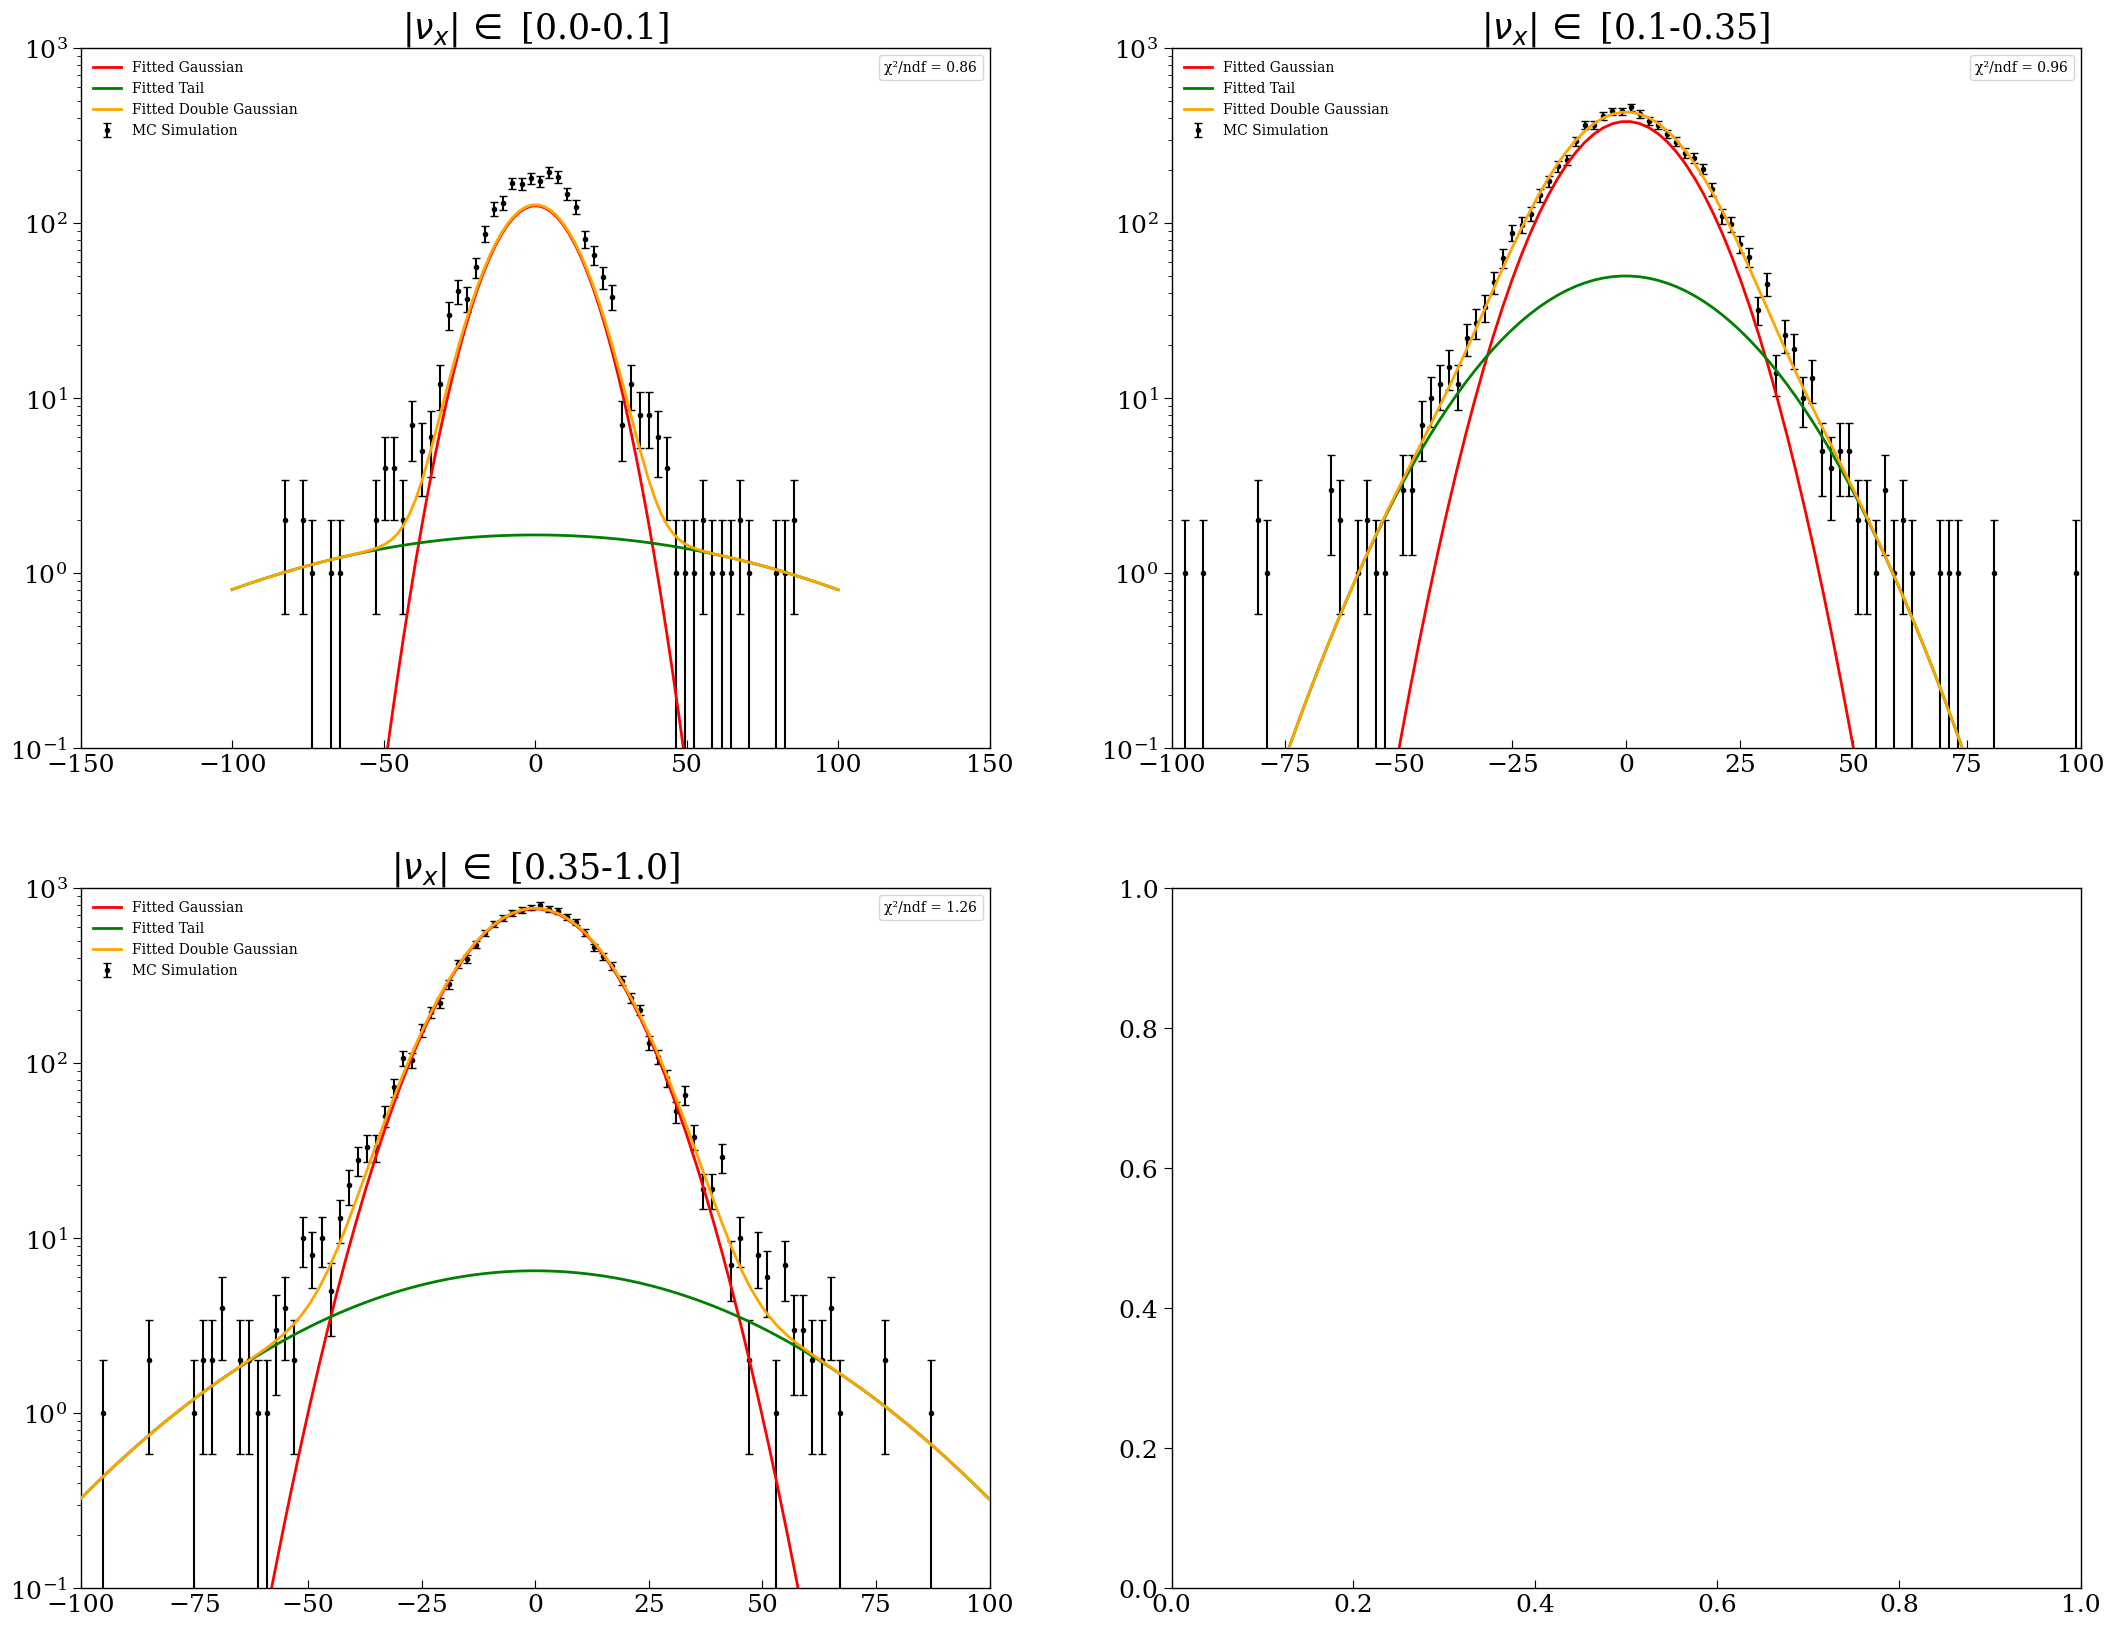

sig_H: -0.0009750163338911426


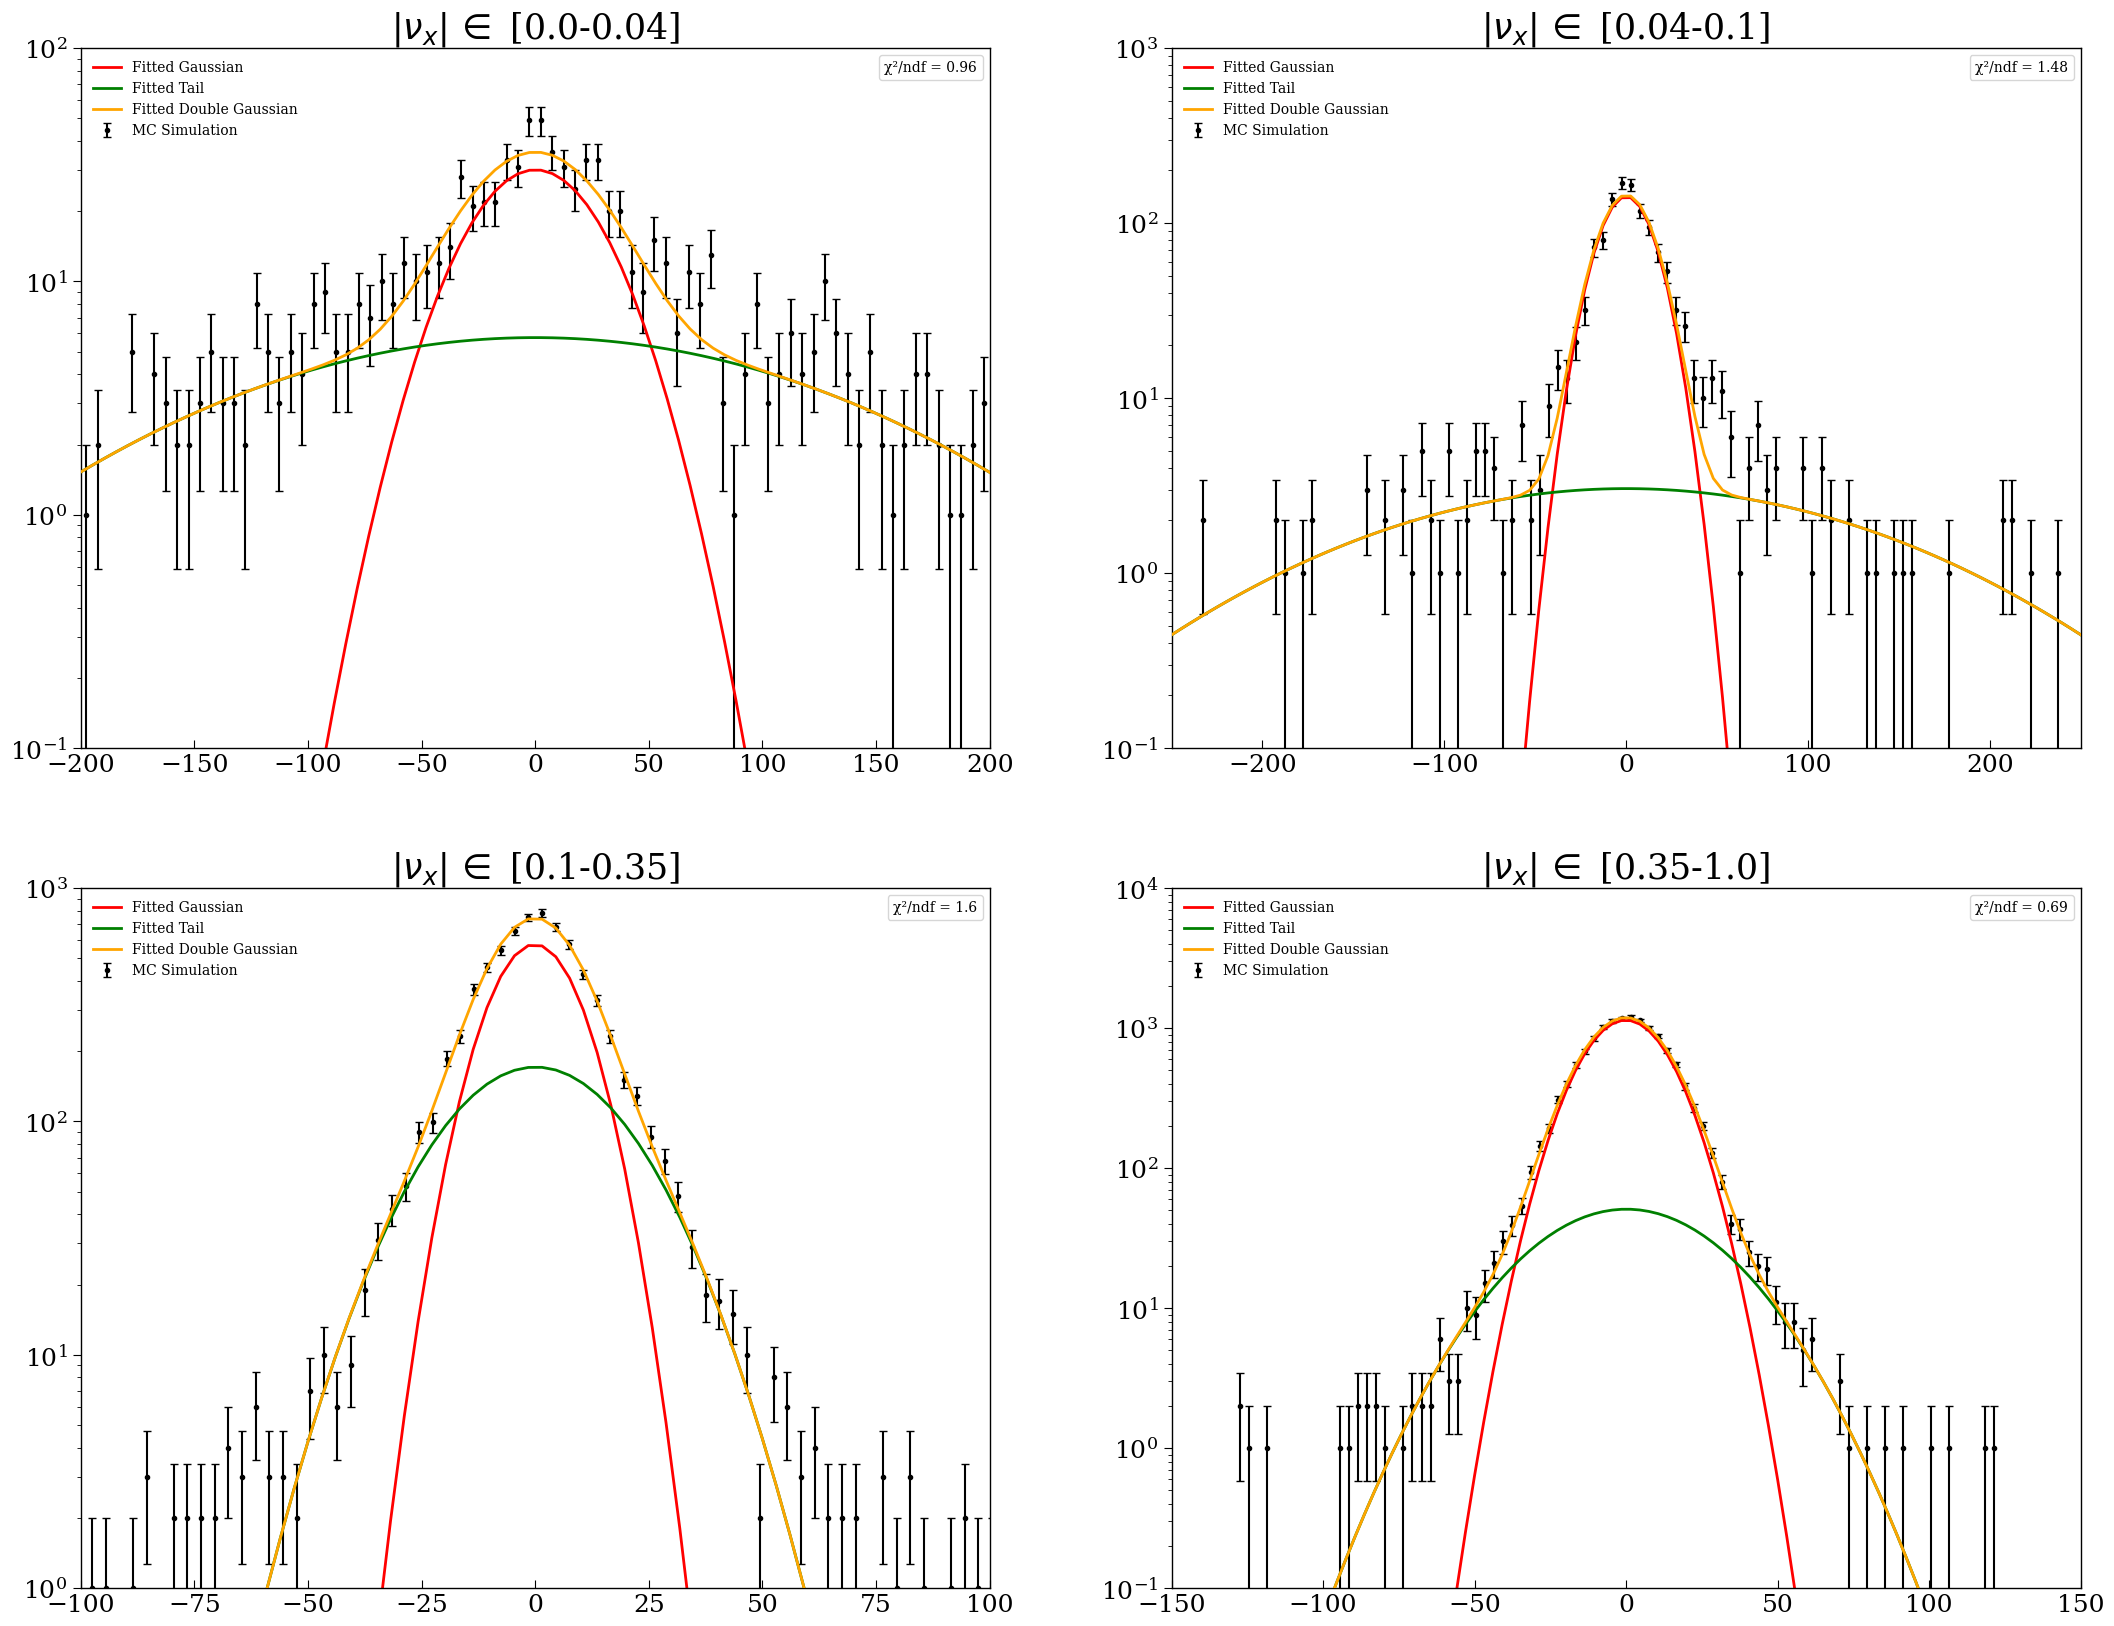

0    12.92
1    12.31
2    13.70
Name: sig_res1, dtype: float64

****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      52.5377
NDf                       =           61
Edm                       =  2.58952e-06
NCalls                    =          847
p0                        =      127.421   +/-   3.60614      	 (limited)
p1                        =     0.987028   +/-   0.00675229   	 (limited)
p2                        =    0.0999996   +/-   0.199558     	 (limited)
p3                        =      12.9205   +/-   0.291183     	 (limited)
p4                        =   -0.0999994   +/-   0.145363     	 (limited)
p5                        =       83.315   +/-   105.145      	 (limited)
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      63.1179
NDf                       =           66
Edm                       =  2.17342e-06
NCalls                    =          974
p0                        =      431.318   +/-   7.75207      	 (limited)
p1          

Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 
Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 


In [11]:
xzPrime_initParams = [[10.,0.8,0.,4.,0.,13.5],[10.,0.8,0.,10.,0.,100],[1000.,0.8,0.,10.,0.,100]]
#xzPrime_initParams = [[10.,0.2,0.,10.,0.,500],[50.,0.2,0.,50.,0.,100],[50.,0.2,0.,50.,0.,100]]
#xzPrime_xranges = [[-80,80],[-100,100],[-100,100]]
xzPrime_xranges = [[-150,150],[-100,100],[-100,100]]

xzPrime_yranges = [[0.1,1000],[0.1,1000],[0.1,1000]]
xzPrime_fitRanges = [[-100,100],[-100,100],[-100,100]]
#xzPrime_sigLims = [-70,70]

yzPrime_initParams = [[10.,0.8,0.,10.,0.,100], [100.,0.8,0.,10.,0.,100.],[10.,0.2,0.,10.,0.,100.],[1000.,0.8,0.,10.,0.,1000.]]
yzPrime_xranges = [[-200,200],[-250,250],[-100,100],[-150,150]]
yzPrime_yranges = [[0.1,100],[0.1,1000],[1,1000],[.1,10000]]
yzPrime_fitRanges = [[-250,250],[-250,250],[-150,150],[-150,150]]
#yzPrime_sigLims = [-250,250]

xz_sig_res = double_gaus_stageZero_v2(muon_gen2, 'dtheta_xz_prime', xranges=xzPrime_xranges, yranges=xzPrime_yranges, initParams=xzPrime_initParams,nbins=1000,rebin=10, tail=True,core=True, fitRange=xzPrime_fitRanges, errdf=True)     
yz_sig_res = double_gaus_stageZero_v2(muon_gen2, 'dtheta_yz_prime', xranges=yzPrime_xranges, yranges=yzPrime_yranges, initParams=yzPrime_initParams,nbins=1000,rebin=10,tail=True,fitRange=yzPrime_fitRanges,errdf=True)

#xz_sig_res = double_gaus_stageZero_v1(muon_gen2, 'dtheta_xz_prime', xranges=xzPrime_xranges, yranges=xzPrime_yranges, initParams=xzPrime_initParams,nbins=1000,rebin=None, tail=True,core=True)     

#sig_res = pd.concat([xz_sig_res,yz_sig_res],axis=0,ignore_index=True)
xz_sig_res["sig_res1"]


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.


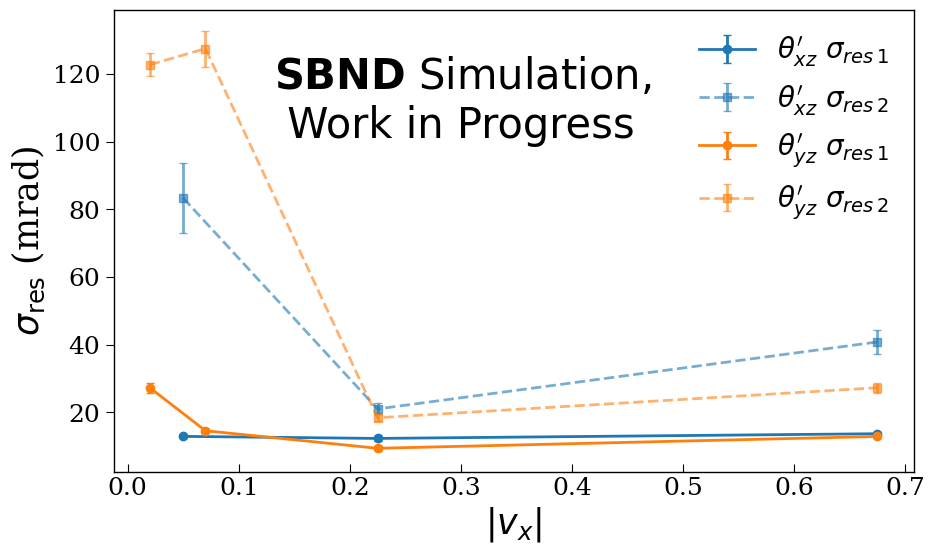

In [16]:
import re

def parse_vx_bin(tune_str):
    """Extract (left, right) |v_x| bin edges from a Tune string like
    'dtheta_yz_prime, |v_x| in [0.0,0.1]'."""
    match = re.search(r'\[([\d.]+),\s*([\d.]+)\]', tune_str)
    if match is None:
        raise ValueError(f"Could not parse |v_x| bin from Tune string: {tune_str!r}")
    return float(match.group(1)), float(match.group(2))


def extract_sigres_arrays(df):
    """
    Given a dgaus_parameters DataFrame from double_gaus_stageZero_v2 (either errdf=True
    or errdf=False format), return arrays: vx_centers, sig_res1, sig_res1_err, sig_res2, sig_res2_err.
    """
    edges = [parse_vx_bin(t) for t in df['Tune']]
    vx_centers = np.array([(l + r) / 2 for l, r in edges])

    if 'sig_res1_err' in df.columns:
        # errdf=True: already numeric
        sig_res1 = df['sig_res1'].to_numpy(dtype=float)
        sig_res1_err = df['sig_res1_err'].to_numpy(dtype=float)
        sig_res2 = df['sig_res2'].to_numpy(dtype=float)
        sig_res2_err = df['sig_res2_err'].to_numpy(dtype=float)
    else:
        # errdf=False: "value ± error" strings need splitting
        def split_val_err(s):
            val_str, err_str = s.split('±')
            return float(val_str), float(err_str)

        s1, s1e = zip(*df['sig_res1'].map(split_val_err))
        s2, s2e = zip(*df['sig_res2'].map(split_val_err))
        sig_res1, sig_res1_err = np.array(s1), np.array(s1e)
        sig_res2, sig_res2_err = np.array(s2), np.array(s2e)

    return vx_centers, sig_res1, sig_res1_err, sig_res2, sig_res2_err


def plot_sigres_vs_vx(df_xz, df_yz):
    vx_xz, s1_xz, s1e_xz, s2_xz, s2e_xz = extract_sigres_arrays(df_xz)
    vx_yz, s1_yz, s1e_yz, s2_yz, s2e_yz = extract_sigres_arrays(df_yz)

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.errorbar(vx_xz, s1_xz, yerr=s1e_xz, fmt='o-', color='tab:blue',
                label=r"$\theta_{xz}'$ $\sigma_{res \, 1}$", capsize=3)
    ax.errorbar(vx_xz, s2_xz, yerr=s2e_xz, fmt='s--', color='tab:blue',
                label=r"$\theta_{xz}'$ $\sigma_{res \, 2}$", capsize=3, alpha=0.6)

    ax.errorbar(vx_yz, s1_yz, yerr=s1e_yz, fmt='o-', color='tab:orange',
                label=r"$\theta_{yz}'$ $\sigma_{res \, 1}$", capsize=3)
    ax.errorbar(vx_yz, s2_yz, yerr=s2e_yz, fmt='s--', color='tab:orange',
                label=r"$\theta_{yz}'$ $\sigma_{res \, 2}$", capsize=3, alpha=0.6)

    ax.set_xlabel(r'$|v_x|$')
    ax.set_ylabel(r'$\sigma_{\mathrm{res}}$ (mrad)')
    ax.legend()

    sbnd.sbnd_sim(ax,0.2,0.9)

    plt.show()

plot_sigres_vs_vx(xz_sig_res, yz_sig_res)

In [35]:
def double_gaus_stageZero_v3(df, column, energyBounds=[0.1, 0.9], maxBin=[0.7, 1.5], sigLims=None,
                           eStep=0.1, xranges=None, yranges=None, initParams=[], nbins=1000, fitRange=None, errdf=False, core=True, tail=False, rebin=None):

    series = df[column]
    initSubList = initParams[-1]

    if fitRange == None: 
        fit_xmin, fit_xmax = -500, 500
    else: fit_xmin, fit_xmax = fitRange[0], fitRange[1]
 

    # --- select rows in the max energy bin ---
    muonEnergies_arr = np.asarray(muonEnergies)
    mask = (muonEnergies_arr >= maxBin[0]) & (muonEnergies_arr < maxBin[1])
    newSeries = series[mask].reset_index(drop=True)
    E_mean = pd.Series(muonEnergies)[mask].mean()
    sig_H = 13.6 / (E_mean * (1 - ((mu_mass_MeV**2) / (E_mean**2))))
    print(f"sig_H: {sig_H}")

    rows = []

    if column == 'dtheta_yz_prime':

        fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(25, 20))
        axs = axs.flatten()

        # only this column needs |v_x| binning
        abs_vx = df.loc[mask, 'v_x_seg0'].abs().reset_index(drop=True)
        vx_bins = [0., 0.04, 0.1, 0.35, 1.]
        n_vx_bins = len(vx_bins) - 1

        # validate xranges up front so a bad input fails loudly, not silently mid-loop
        if xranges is not None and len(xranges) != n_vx_bins:
            raise ValueError(
                f"xranges has {len(xranges)} entries but there are {n_vx_bins} |v_x| bins; "
                f"pass one [xmin, xmax] pair per bin (or None to use defaults)."
            )
        if yranges is not None and len(yranges) != n_vx_bins:
            raise ValueError(
                f"yranges has {len(yranges)} entries but there are {n_vx_bins} |v_x| bins; "
                f"pass one [xmin, xmax] pair per bin (or None to use defaults)."
            )

        counter = 0
        for left, right in zip(vx_bins[:-1], vx_bins[1:]):
            initSubList = initParams[counter]
            currentRange_fit = fitRange[counter]
            fit_xmin, fit_xmax = currentRange_fit[0], currentRange_fit[1]
            bin_series = newSeries[(abs_vx > left) & (abs_vx < right)]
            if rebin is not None: sig_res1, sig_res1_err, sig_res2, sig_res2_err, fitParams, fitParErrors, fitScore, numBins, numBins_r = fit_sigma_res(bin_series, sig_H, initSubList,
                                                fit_xmin, fit_xmax, nbins, rebin=rebin,sigLims=sigLims)
            else: sig_res1, sig_res1_err, sig_res2, sig_res2_err, fitParams, fitParErrors, fitScore, numBins = fit_sigma_res(bin_series, sig_H, initSubList,
                                                fit_xmin, fit_xmax, nbins,sigLims=sigLims)
            if errdf:
                rows.append({
                    'Tune': f"θ'_yz, |v_x| in [{left},{right}]",
                    'sig_res1': round(sig_res1,2),
                    'sig_res1_err': round(sig_res1_err,2),
                    'sig_res2': round(sig_res2,2),
                    'sig_res2_err': round(sig_res2_err,2)
                })
            else:
                rows.append({
                    'Tune': f"θ'_yz, |v_x| in [{left},{right}]",
                    'sig_res1': f'{round(sig_res1,2)} ± {round(sig_res1_err,2)}',
                    'sig_res2': f'{round(sig_res2,2)} ± {round(sig_res2_err,2)}',
                })

            if rebin is not None:
                if numBins_r==numBins:
                    raise ValueError(f"{numBins} = {numBins_r} -- number of bins in histogram does not change even after .Rebin." 
                                        +" Check fit_sigma_res for bugs (likely has to do with .Rebin function.)")
            
            scale,frac,mu_1_0,sigma_1_0,mu_2_0,sigma_2_0 = fitParams[0], fitParams[1],fitParams[2],fitParams[3],fitParams[4],fitParams[5]
            #print(fitParams)

            if rebin is not None: bin_heights, bin_borders = np.histogram(bin_series, bins=numBins_r, range=(fit_xmin, fit_xmax))
            else: bin_heights, bin_borders = np.histogram(newSeries, bins=numBins, range=(fit_xmin, fit_xmax))
            bin_centers = (bin_borders[:-1] + bin_borders[1:]) / 2
            axs[counter].errorbar(bin_centers, bin_heights, yerr=np.sqrt(bin_heights), fmt='o', color='black', gapcolor='purple', label='Data',markersize=3, capsize=3, linewidth=1.5, zorder=1)

            axs[counter].set_yscale('log')

            if rebin is not None: x = np.linspace(fit_xmin, fit_xmax, numBins_r)
            else: x = np.linspace(fit_xmin, fit_xmax, numBins)
            pdf = scale *frac * (1/((2*math.pi*(sigma_1_0**2))**0.5)) * np.exp(-0.5 * (((x - mu_1_0) / sigma_1_0) ** 2)) #Probability for core gaus
            pdf_tail = scale*(1-frac)* (1/((2*math.pi*(sigma_2_0**2))**0.5)) * np.exp(-0.5 * (((x - mu_2_0) / sigma_2_0) ** 2)) #PDF for tail gaus
            double_pdf = pdf + pdf_tail

            if core: axs[counter].plot(x, pdf, color='red', linewidth=2, label='Fitted Gaussian',zorder=2)
            if tail: axs[counter].plot(x, pdf_tail, color='green', linewidth=2, label='Fitted Tail',zorder=3)
            axs[counter].plot(x, double_pdf, color='orange', linewidth=2, label=f'Fitted Double Gaussian', zorder=4)

            # main legend (Data / Fitted Gaussian / Fitted Tail / Fitted Double Gaussian)
            main_legend = axs[counter].legend(loc='upper left', fontsize=10)
            axs[counter].add_artist(main_legend)  # keep it — otherwise the next legend() call below replaces it

            axs[counter].set_title(r"$|\nu_{x}| \, \in$" + f" [{left}-{right}]")

            # separate, text-only legend showing this subplot's chi2/ndf
            chi2_handle = mlines.Line2D([], [], color='none',
                                         label=f'χ²/ndf = {round(fitScore[2], 2)}')
            axs[counter].legend(handles=[chi2_handle], loc='upper right', fontsize=10,
                                 frameon=True, handlelength=0, handletextpad=0)

            #if counter==0: axs[0].legend(loc='upper left', fontsize=10)
            bin_yrange = yranges[counter] if yranges is not None else None
            if bin_yrange is not None:
                axs[counter].set_ylim(bin_yrange[0], bin_yrange[1])
            else:
                axs[counter].set_ylim(0.1, 1000)

            # per-subplot x-range: use the user-supplied pair if given, else default fit range
            bin_xrange = xranges[counter] if xranges is not None else None
            if bin_xrange is not None:
                axs[counter].set_xlim(bin_xrange[0], bin_xrange[1])
            else:
                axs[counter].set_xlim(fit_xmin, fit_xmax)

            counter += 1

    else:
        fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(25, 20))
        axs = axs.flatten()

        # only this column needs |v_x| binning
        abs_vx = df.loc[mask, 'v_x_seg0'].abs().reset_index(drop=True)
        vx_bins = [0., 0.1, 0.35, 1.]
        n_vx_bins = len(vx_bins) - 1

        # validate xranges up front so a bad input fails loudly, not silently mid-loop
        if xranges is not None and len(xranges) != n_vx_bins:
            raise ValueError(
                f"xranges has {len(xranges)} entries but there are {n_vx_bins} |v_x| bins; "
                f"pass one [xmin, xmax] pair per bin (or None to use defaults)."
            )
        if yranges is not None and len(yranges) != n_vx_bins:
            raise ValueError(
                f"yranges has {len(yranges)} entries but there are {n_vx_bins} |v_x| bins; "
                f"pass one [xmin, xmax] pair per bin (or None to use defaults)."
            )

        counter = 0
        for left, right in zip(vx_bins[:-1], vx_bins[1:]):
            initSubList = initParams[counter]
            currentRange_fit = fitRange[counter]
            fit_xmin, fit_xmax = currentRange_fit[0], currentRange_fit[1]
            bin_series = newSeries[(abs_vx > left) & (abs_vx < right)]
            if rebin != None: sig_res1, sig_res1_err, sig_res2, sig_res2_err, fitParams, fitParErrors, fitScore, numBins, numBins_r = fit_sigma_res(bin_series, sig_H, initSubList,
                                                fit_xmin, fit_xmax, nbins, rebin=rebin,sigLims=sigLims)
            else: sig_res1, sig_res1_err, sig_res2, sig_res2_err, fitParams, fitParErrors, fitScore, numBins = fit_sigma_res(bin_series, sig_H, initSubList,
                                                fit_xmin, fit_xmax, nbins,sigLims=sigLims)
            if errdf:
                rows.append({
                    'Tune': f"θ'_xz, |v_x| in [{left},{right}]",
                    'sig_res1': round(sig_res1,2),
                    'sig_res1_err': round(sig_res1_err,2),
                    'sig_res2': round(sig_res2,2),
                    'sig_res2_err': round(sig_res2_err,2)
                })
            else:
                rows.append({
                    'Tune': f"θ'_xz, |v_x| in [{left},{right}]",
                    'sig_res1': f'{round(sig_res1,2)} ± {round(sig_res1_err,2)}',
                    'sig_res2': f'{round(sig_res2,2)} ± {round(sig_res2_err,2)}',
                })
            
            scale,frac,mu_1_0,sigma_1_0,mu_2_0,sigma_2_0 = fitParams[0], fitParams[1],fitParams[2],fitParams[3],fitParams[4],fitParams[5]
            #print(fitParams)

            if rebin is not None: bin_heights, bin_borders = np.histogram(bin_series, bins=numBins_r, range=(fit_xmin, fit_xmax))
            else: bin_heights, bin_borders = np.histogram(newSeries, bins=numBins, range=(fit_xmin, fit_xmax))
            bin_centers = (bin_borders[:-1] + bin_borders[1:]) / 2
            axs[counter].errorbar(bin_centers, bin_heights, yerr=np.sqrt(bin_heights), fmt='o', color='black', gapcolor='purple', label='Data',markersize=3, capsize=3, linewidth=1.5, zorder=1)

            axs[counter].set_yscale('log')

            if rebin is not None: x = np.linspace(fit_xmin, fit_xmax, numBins_r)
            else: x = np.linspace(fit_xmin, fit_xmax, numBins)
            #Probability for core gaus
            pdf = scale *frac * (1/((2*math.pi*(sigma_1_0**2))**0.5)) * np.exp(-0.5 * (((x - mu_1_0) / sigma_1_0) ** 2)) 
            #Probability for tail gaus
            pdf_tail = scale *(1-frac) * (1/((2*math.pi*(sigma_2_0**2))**0.5)) * np.exp(-0.5 * (((x - mu_2_0) / sigma_2_0) ** 2)) 
            double_pdf = pdf + pdf_tail

            if core: axs[counter].plot(x, pdf, color='red', linewidth=2, label='Fitted Gaussian',zorder=2)
            if tail: axs[counter].plot(x, pdf_tail, color='green', linewidth=2, label='Fitted Tail',zorder=3)
            axs[counter].plot(x, double_pdf, color='orange', linewidth=2, label=f'Fitted Double Gaussian', zorder=4)

            # main legend (Data / Fitted Gaussian / Fitted Tail / Fitted Double Gaussian)
            main_legend = axs[counter].legend(loc='upper left', fontsize=10)
            axs[counter].add_artist(main_legend)  # keep it — otherwise the next legend() call below replaces it

            axs[counter].set_title(r"$|\nu_{x}| \, \in$" + f" [{left}-{right}]")

            # separate, text-only legend showing this subplot's chi2/ndf
            chi2_handle = mlines.Line2D([], [], color='none',
                                         label=f'χ²/ndf = {round(fitScore[2], 2)}')
            axs[counter].legend(handles=[chi2_handle], loc='upper right', fontsize=10,
                                 frameon=True, handlelength=0, handletextpad=0)

            #if counter==0: axs[0].legend(loc='upper left', fontsize=10)
            bin_yrange = yranges[counter] if yranges is not None else None
            if bin_yrange is not None:
                axs[counter].set_ylim(bin_yrange[0], bin_yrange[1])
            else:
                axs[counter].set_ylim(0.1, 1000)

            # per-subplot x-range: use the user-supplied pair if given, else default fit range
            bin_xrange = xranges[counter] if xranges is not None else None
            if bin_xrange is not None:
                axs[counter].set_xlim(bin_xrange[0], bin_xrange[1])
            else:
                axs[counter].set_xlim(fit_xmin, fit_xmax)

            counter += 1

    plt.show()

    if errdf: return pd.DataFrame(rows, columns=['Tune', 'sig_res1', 'sig_res1_err','sig_res2', 'sig_res2_err'])
    else: return pd.DataFrame(rows, columns=['Tune', 'sig_res1','sig_res2'])

sig_H: -0.0009750163338911426


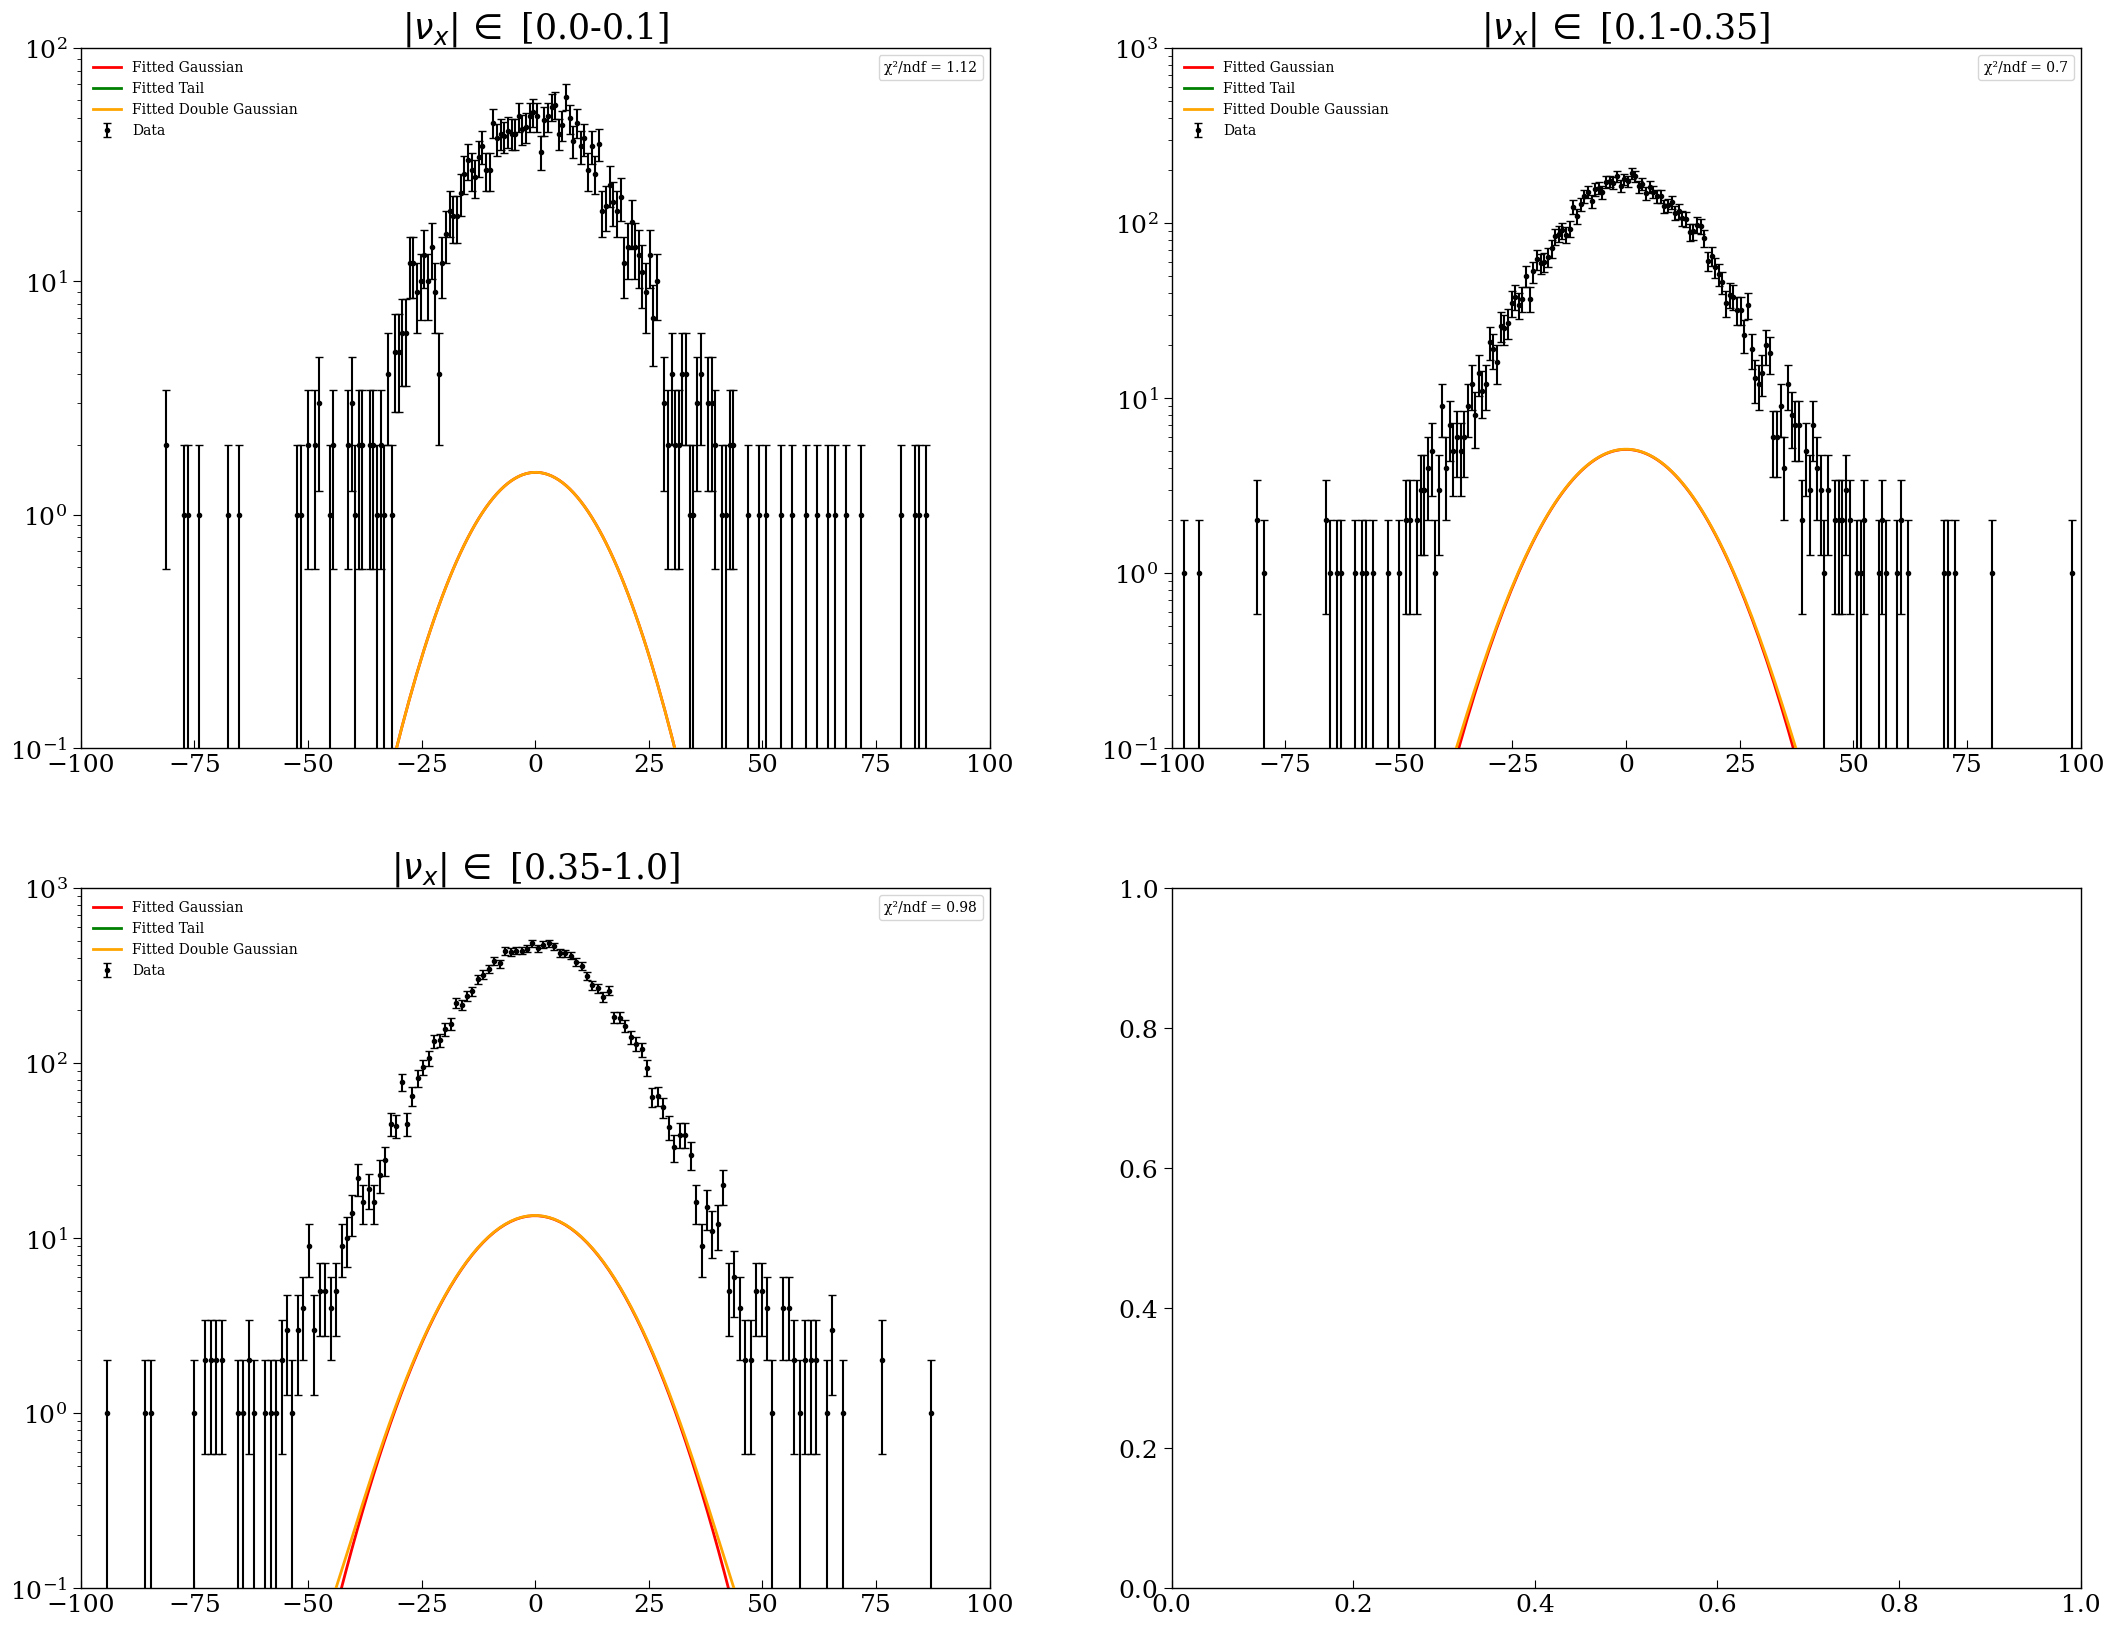

sig_H: -0.0009750163338911426


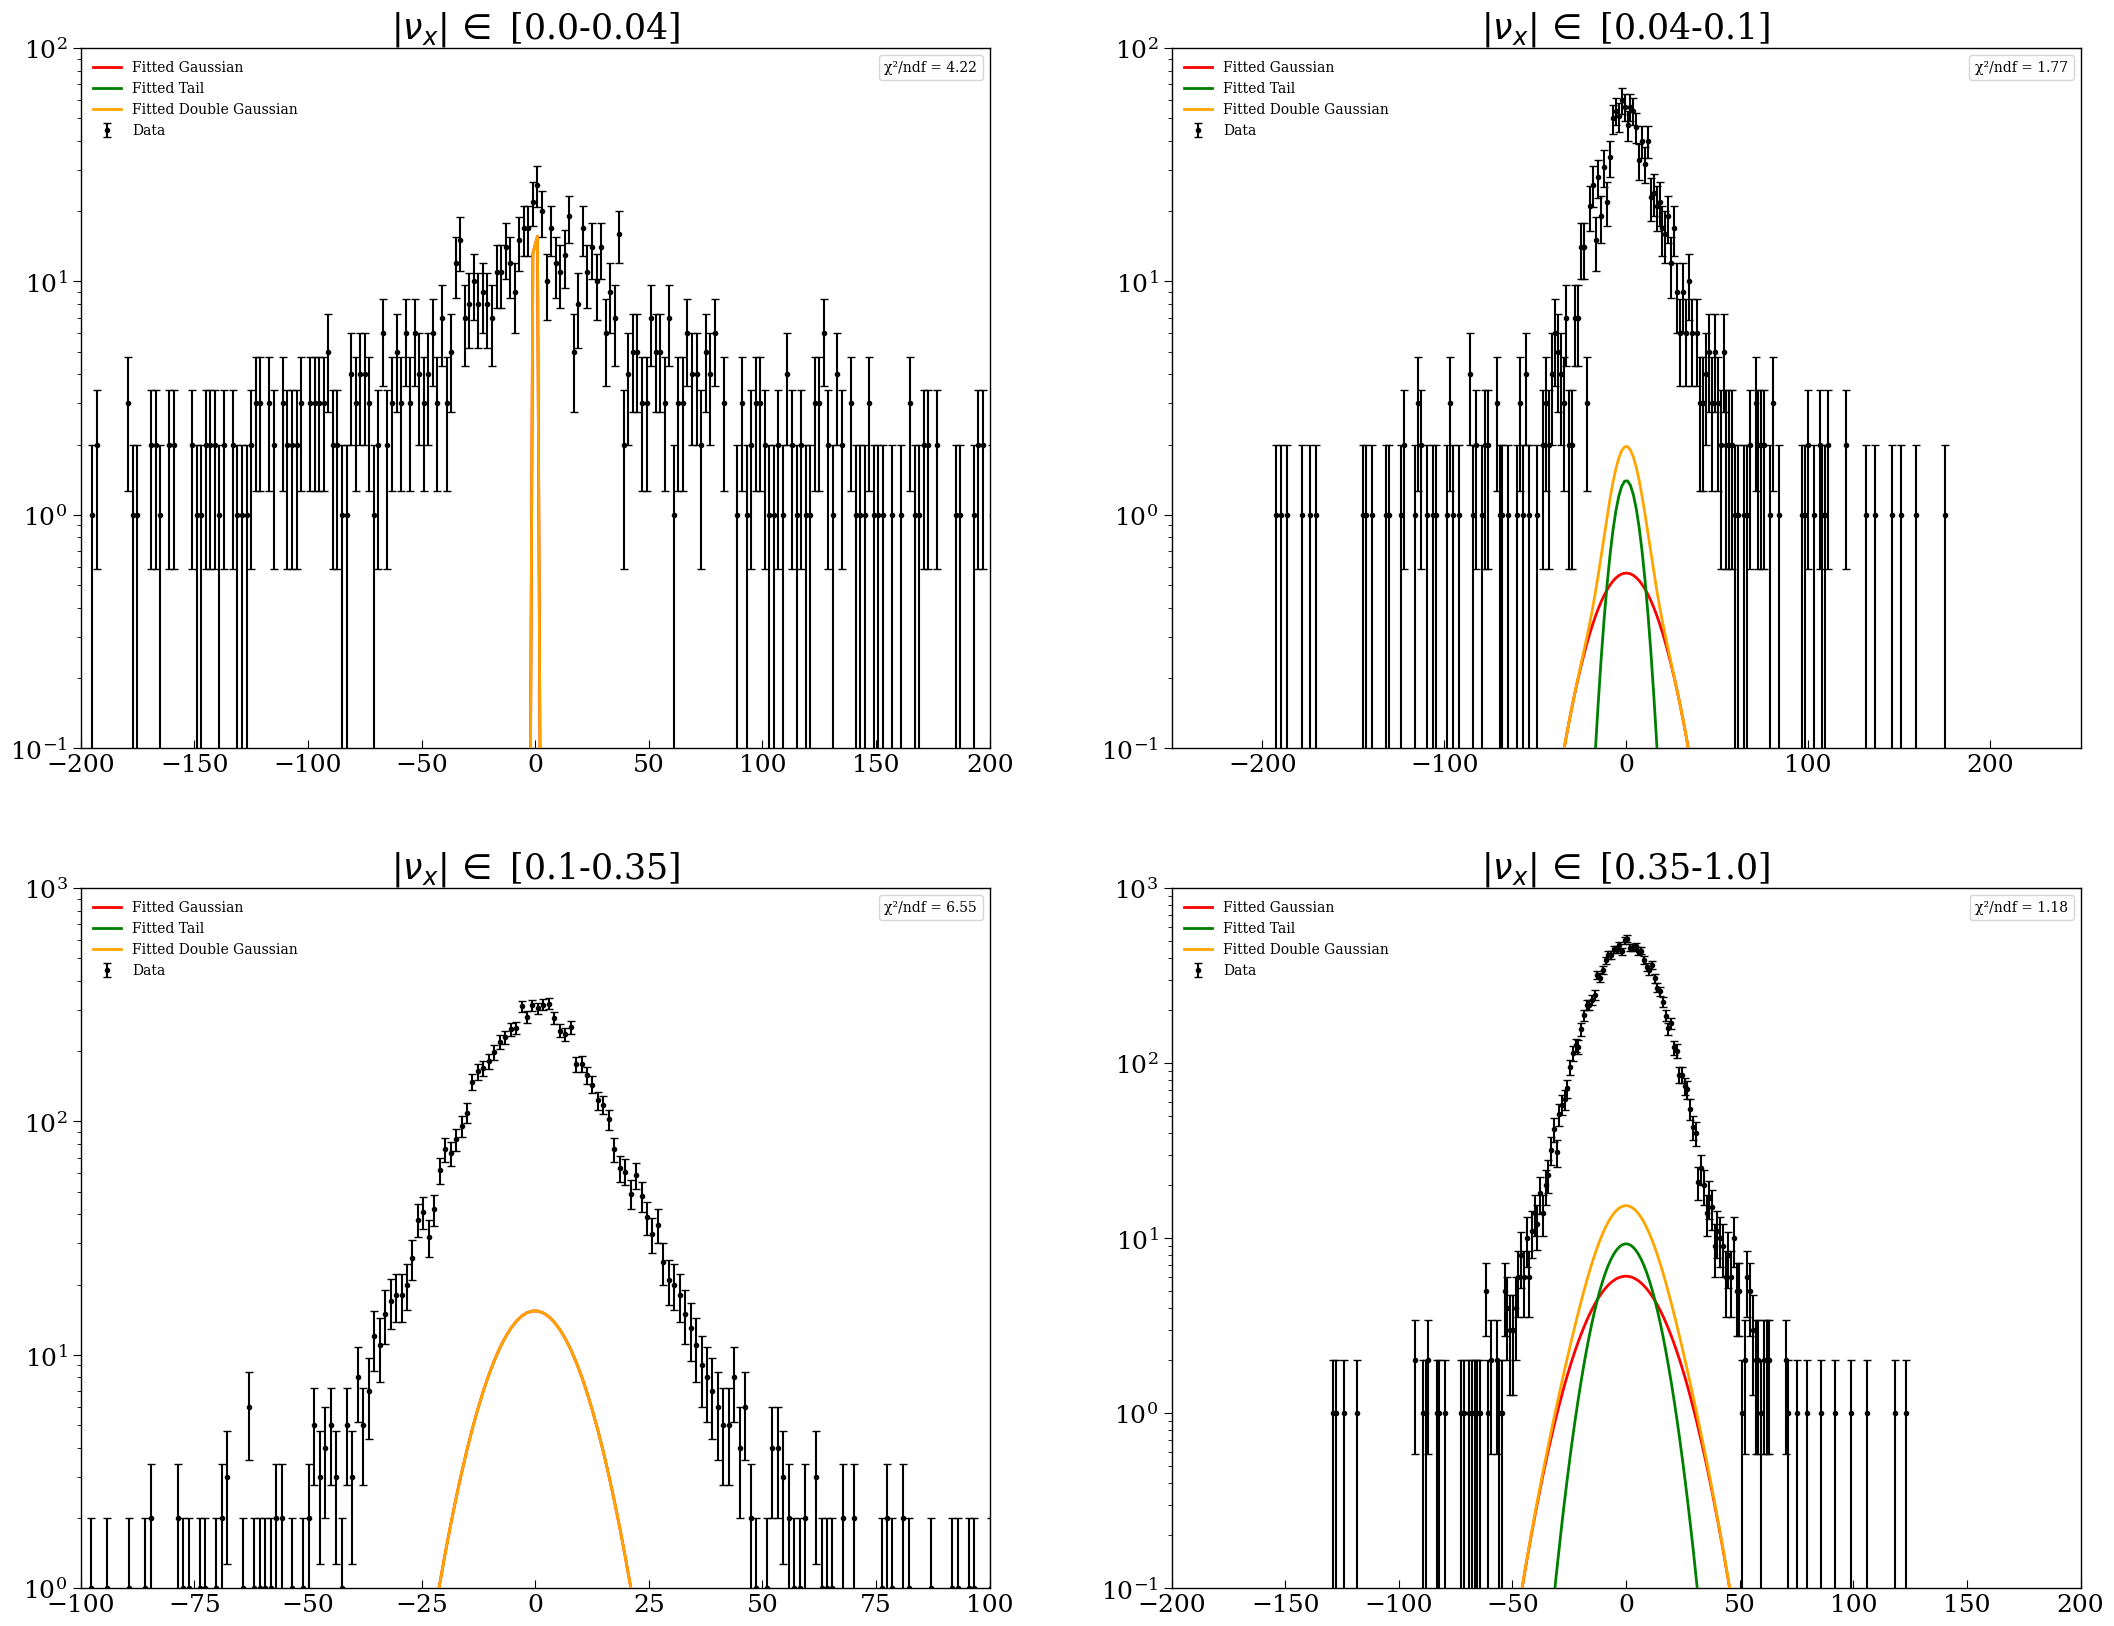

,Tune,sig_res1,sig_res2
0,"θ'_xz, |v_x| in [0.0,0.1]",13.12 ± 0.32,0.01 ± 0.01
1,"θ'_xz, |v_x| in [0.1,0.35]",13.12 ± 0.42,61.29 ± 5.14
2,"θ'_xz, |v_x| in [0.35,1.0]",13.6 ± 0.39,43.69 ± 3.75
3,"θ'_yz, |v_x| in [0.0,0.04]",0.66 ± 0.22,0.1 ± 0.07
4,"θ'_yz, |v_x| in [0.04,0.1]",18.36 ± 0.86,7.36 ± 0.9
5,"θ'_yz, |v_x| in [0.1,0.35]",9.02 ± 0.0,0.0 ± 0.0
6,"θ'_yz, |v_x| in [0.35,1.0]",15.94 ± 0.38,10.41 ± 0.52


****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      140.139
NDf                       =          125
Edm                       =  2.41297e-09
NCalls                    =          323
p0                        =      99.9967   +/-   2.53346      	 (limited)
p1                        =     0.500052   +/-   3.63635e-05  	 (limited)
p2                        =          0.1   +/-   0.000982513  	 (limited)
p3                        =      13.1185   +/-   0.104865     	 (limited)
p4                        =    0.0993857   +/-   0.00133352   	 (limited)
p5                        =   0.00825159   +/-   0.000128153  	 (limited)
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      99.5747
NDf                       =          143
Edm                       =  5.97905e-06
NCalls                    =          741
p0                        =       169.73   +/-   2.68149      	 (limited)
p1          

Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 
Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 
Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 
Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 
Warning in <Fit>: Abnormal termination of minimization.
Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 
Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 
Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 
Info in <ROOT::Math::ParameterSett

In [36]:
xzPrime_initParams = [[1000.,0.8,0.,10.,0.,100],[100000.,0.8,0.,10.,0.,100],[1000.,0.2,0.,15.,0.,150]]
#xzPrime_initParams = [[10.,0.2,0.,10.,0.,500],[50.,0.2,0.,50.,0.,100],[50.,0.2,0.,50.,0.,100]]
xzPrime_xranges = [[-100,100],[-100,100],[-100,100]]
xzPrime_yranges = [[0.1,100],[0.1,1000],[0.1,1000]]
xzPrime_fitRanges = [[-100,100],[-100,100],[-150,150]]
#xzPrime_sigLims = [-70,70]

yzPrime_initParams = [[10000.,0.8,0.,50.,0.,120], [10000.,0.8,0.,10.,0.,100.],[10000.,0.2,0.,10.,0.,500.],[10000.,0.02,0.,500.,0.,1000.]]
yzPrime_xranges = [[-200,200],[-250,250],[-100,100],[-200,200]]
yzPrime_yranges = [[0.1,100],[0.1,100],[1,1000],[.1,1000]]
yzPrime_fitRanges = [[-250,250],[-200,200],[-150,150],[-150,150]]
#yzPrime_sigLims = [-250,250]

xz_sig_res = double_gaus_stageZero_v3(muon_gen2, 'dtheta_xz_prime', xranges=xzPrime_xranges, yranges=xzPrime_yranges, initParams=xzPrime_initParams,nbins=1000,rebin=4, tail=True,core=True, fitRange=xzPrime_fitRanges)     
yz_sig_res = double_gaus_stageZero_v3(muon_gen2, 'dtheta_yz_prime', xranges=yzPrime_xranges, yranges=yzPrime_yranges, initParams=yzPrime_initParams,nbins=1000,rebin=4,tail=True,fitRange=yzPrime_fitRanges)


sig_res = pd.concat([xz_sig_res,yz_sig_res],axis=0,ignore_index=True)
sig_res


In [18]:
# tuning sigma_1: sigma_2 and A are free parameters

def sigma1_fit(series,sig_res_arr,sig_H,meanEnergy,nbins=1000,fitRanges=None,initSubList=None,rebin=None):
    func = TF1('func', ROOT.double_gaus_norm, fit_xmin, fit_xmax, 6)
    if initSubList is None:
        raise ValueError(
            f"List for initial parameters is empty. Did you pass in a list?"
        )
    elif len(initSubList)<6:
        raise ValueError(
            f"Length of list for initial parameters is less than 6: {len(initSubList)}<6. Did you pass in enough values?"
        )
    func.SetParameters(*initSubList[:6])

    #fit range for scale factor
    func.SetParLimits(0, 0., 10000.)
    #range for area fraction, since it is not being tuned
    func.SetParLimits(1,0.5,1.)

    # fix value for sigma1
    kappa = 1. #placeholder for kappa (for now)
    fixed_sig1 = (((2/3)*kappa*sig_H)+sig_res)**0.5
    func.FixParameter(3, fixed_sig1) #this is sigma1, the parameter being tuned

    #range for sigma 2, since it is not being tuned
    func.SetParLimits(5, 0,60)

    #fit ranges for mu
    func.SetParLimits(2, -0.1, 0.1)
    func.SetParLimits(4, -0.1, 0.1)

    hist = th1_from_series(series, name='roothist', nbins=nbins, xmin=fit_xmin, xmax=fit_xmax)
    numBins1 = hist.GetNbinsX()

    #th1_max = hist.GetMaximum()
    if rebin is not None: 
        hist.Rebin(rebin)
        numBins2 = hist.GetNbinsX()

    hist.Fit(func, "S")

    sigma_1_1, sigma_1_1_err = func.GetParameter(3), func.GetParError(3)
    sigma_2_1, sigma_2_1_err = func.GetParameter(5), func.GetParError(5)

    scale, frac, mu_1_1, mu_2_1 = func.GetParameter(0), func.GetParameter(1), func.GetParameter(2), func.GetParameter(4)
    frac_err, mu_1_1_err, mu_2_1_err = func.GetParError(1), func.GetParError(2), func.GetParError(4)

    chi2 = func.GetChisquare()
    ndf = func.GetNDF()
    chi2_ndf = chi2/ndf

    fitParams, fitParErrors, score = [scale,frac,mu_1_1,sigma_1_1,mu_2_1,sigma_2_1], [frac_err,mu_1_1_err,sigma_1_1_err,mu_2_1_err,sigma_2_1_err], [chi2,ndf,chi2_ndf]

    if rebin is not None: return sigma_1_1, sigma_2_1, fitParams, fitParErrors, score, numBins1, numBins2
    else: return sigma_1_1, sigma_2_1, fitParams, fitParErrors, score, numBins1

def double_gaus_subplots_sigma1(df, column, sig_res1, energyBounds=[0.1, 0.9], maxBin=[0.7, 1.5], eStep=0.1,
                                 initParams=[], xranges=None, yranges=None, xname="",
                                 core=False, tail=False, nbins=1000, fitRanges=None,
                                 rebin=None):
    """
    Step 2 of the iterative tuning procedure: fits sigma1 (and scale, mu1, mu2, which stay
    floating), while A and sigma2 are fixed to values from a previous fit stage.

    initParams  : list of [scale, frac, mu1, sigma1, mu2, sigma2] per energy bin — initial
                  guess passed straight into sigma1_fit's TF1.
    fixedParams : list of [A_fix, sigma2_fix] per energy bin — the two values fixed by
                  sigma1_fit; everything else (scale, mu1, sigma1, mu2) floats.
    """
    series = df[column]

    # --- mean energy in maxBin, used to compute sig_H for sig_res1 ---
    muonEnergies_arr = np.asarray(muonEnergies)
    mask = (muonEnergies_arr >= maxBin[0]) & (muonEnergies_arr < maxBin[1])
    E_mean = pd.Series(muonEnergies_arr)[mask].mean()
    sig_H = 13.6 / (E_mean * (1 - ((mu_mass_MeV**2) / (E_mean**2))))

    eb1, eb2 = energyBounds[0], energyBounds[1]

    energyBins = []
    energy = eb1
    while energy < eb2:
        energyBins.append(round(energy, 2))
        energy += eStep

    # cut to this column's data within [eb1, eb2]
    energy_mask = (muonEnergies_arr > eb1) & (muonEnergies_arr < eb2)
    seriesNew = series[energy_mask].reset_index(drop=True)
    energyNew = pd.Series(muonEnergies_arr[energy_mask]).reset_index(drop=True)

    fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(25, 20), sharey=True)
    axs = axs.flatten()

    df_list = []
    for i in range(len(energyBins) - 1):
        xrange_i = xranges[i] if len(xranges) > 1 else xranges[0]
        xmin, xmax = xrange_i[0], xrange_i[1]
        yrange_i = yranges[i] if len(yranges) > 1 else xranges[0]
        ymin, ymax = yrange_i[0], yrange_i[1]

        fitRange_i = fitRanges[i] if len(fitRanges) > 1 else fitRanges[0]
        fit_xmin, fit_xmax = fitRange_i[0], fitRange_i[1]

        e1, e2 = energyBins[i], energyBins[i + 1]
        bin_mask = (energyNew >= e1) & (energyNew <= e2)
        seriesNew2 = seriesNew[bin_mask].reset_index(drop=True)

        initSubList = initParams[i]

        if rebin is not None:
            sigma1, sigma2, fitParams, fitParErrors, fitScore, numBins1, numBins2 = sigma1_fit(
                seriesNew2, sig_res1, sig_H, nbins=nbins, fit_xmin=fit_xmin, fit_xmax=fit_xmax,
                initSubList=initSubList, rebin=rebin)
        else:
            sigma1, sigma2, fitParams, fitParErrors, fitScore, numBins1 = sigma1_fit(
                seriesNew2, sig_res1, sig_H, nbins=nbins, fit_xmin=fit_xmin, fit_xmax=fit_xmax,
                initSubList=initSubList)
            numBins2 = numBins1

        scale, frac, mu_1, sigma_1, mu_2, sigma_2 = fitParams
        chi2, ndf, chi2_ndf = fitScore

        sig_res1 = ((sigma_1**2) - ((2/3) * (sig_H**2)))**0.5

        bin_heights, bin_borders = np.histogram(seriesNew2, bins=numBins2, range=(fit_xmin, fit_xmax))
        bin_centers = (bin_borders[:-1] + bin_borders[1:]) / 2

        x = np.linspace(fit_xmin, fit_xmax, numBins2)
        pdf = scale * frac * np.exp(-0.5 * ((x - mu_1) / sigma_1) ** 2)
        pdf_tail = scale * (1 - frac) * np.exp(-0.5 * ((x - mu_2) / sigma_2) ** 2)
        double_pdf = pdf + pdf_tail

        axs[i].errorbar(bin_centers, bin_heights, yerr=np.sqrt(bin_heights), fmt='', color='blue',
                         alpha=0.3, label='Error', markersize=2, capsize=3, linewidth=0.5, zorder=1)
        axs[i].scatter(x, bin_heights, color='black', label='Data', s=10)
        axs[i].set_yscale('log')
        if core: axs[i].plot(x, pdf, color='red', linewidth=2, label='Fitted Gaussian', zorder=2)
        if tail: axs[i].plot(x, pdf_tail, color='green', linewidth=2, label='Fitted Tail', zorder=3)
        axs[i].plot(x, double_pdf, color='orange', linewidth=2,
                    label=f'Fitted Double Gaussian \n' + r'$\chi^2$/NDf' + f"={round(chi2,2)}/{ndf}", zorder=4)
        axs[i].set_title(r"Local $KE_{\mu} \, \in$ " + f"[{e1}-{e2}] GeV")
        axs[i].set_xlabel(xname, loc='right')
        axs[i].legend(loc='upper left', fontsize=10)
        axs[i].set_xlim(xmin, xmax)

        ser = pd.Series([sigma_1, fitParErrors[2], sig_res1, chi2_ndf],
                         index=['sigma1', 'sigma1_err', 'sig_res1', 'chi2_ndf'])
        df2 = pd.DataFrame({f"KE in [{e1}-{e2}]": ser})
        df_list.append(df2)

    xvarCol = pd.Series([np.nan, np.nan, np.nan, np.nan],
                         index=['sigma1', 'sigma1_err', 'sig_res1', 'chi2_ndf'])
    xvarDf = pd.DataFrame({column: xvarCol})
    df_list.insert(0, xvarDf)
    dgaus_parameters = pd.concat(df_list, axis=1)

    axs[0].set_ylim(ymin, ymax)
    fig.text(0.08, 0.5, 'Probability Density', va='center', rotation='vertical', size='xx-large')
    plt.tight_layout()
    plt.show()

    return dgaus_parameters

sig_H: -0.0009750163338911426


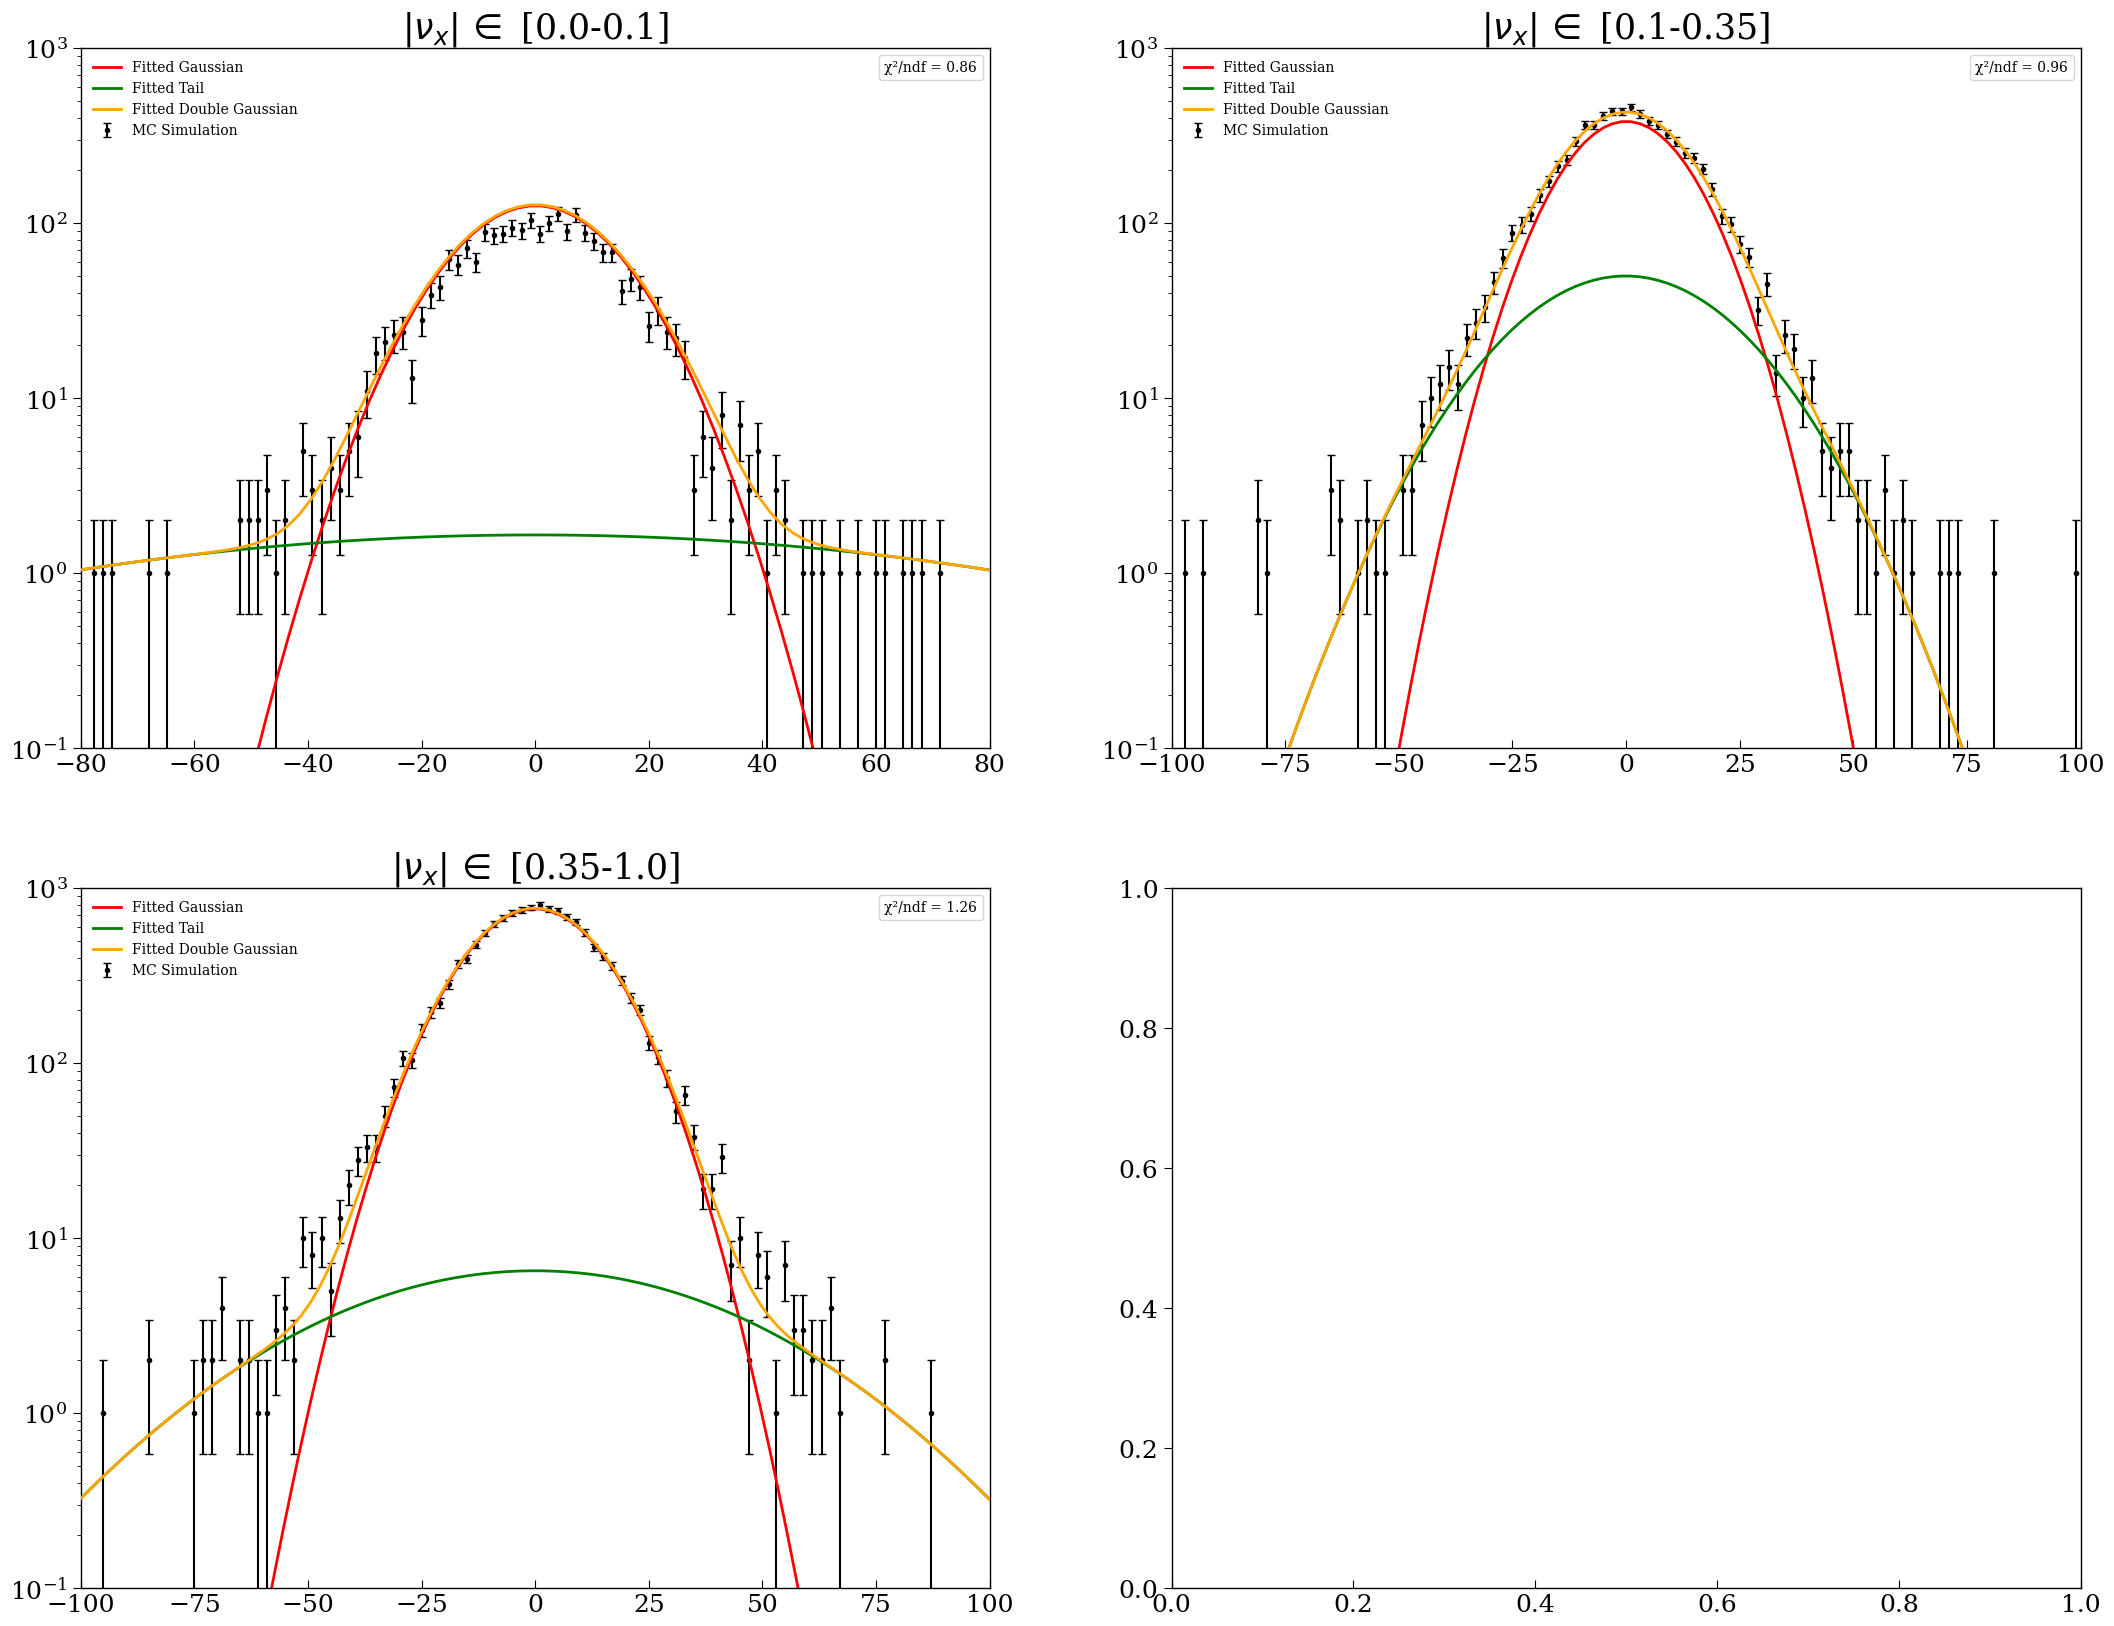

sig_H: -0.0009750163338911426


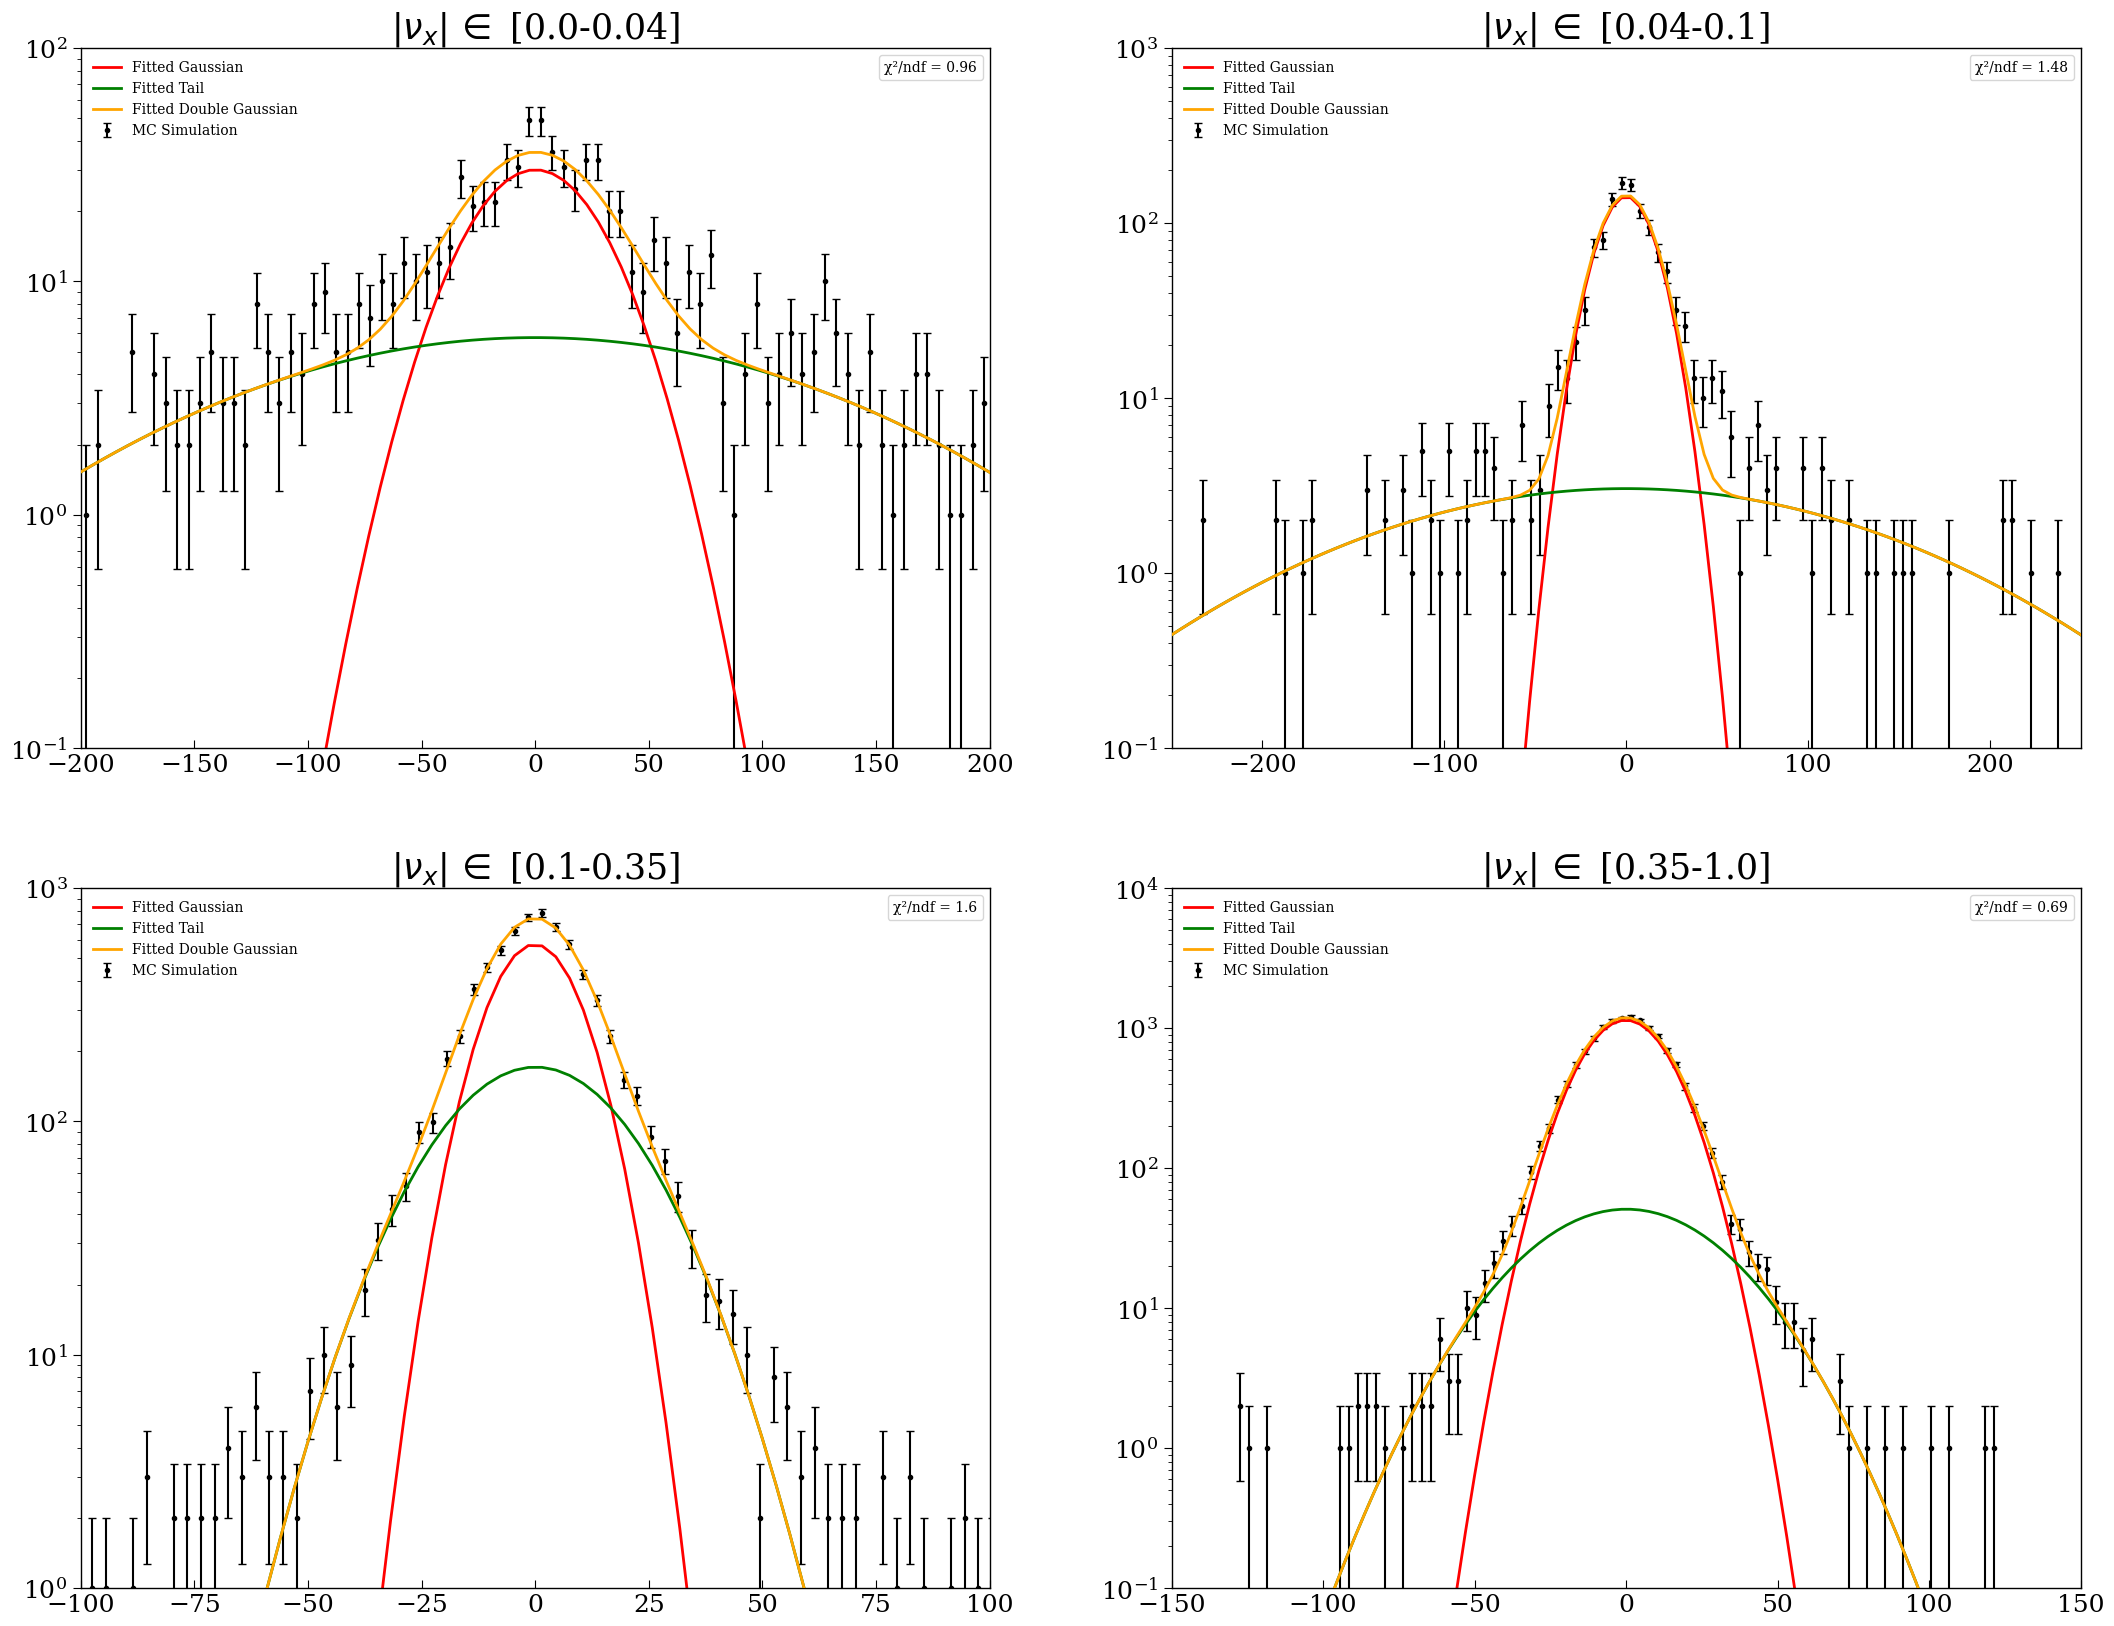

,Tune,sig_res1,sig_res1_err,sig_res2,sig_res2_err
0,"dtheta_xz_prime, |v_x| in [0.0,0.1]",12.92,0.54,83.31,10.25
1,"dtheta_xz_prime, |v_x| in [0.1,0.35]",12.31,0.74,21.02,1.63
2,"dtheta_xz_prime, |v_x| in [0.35,1.0]",13.70,0.38,40.80,3.50


****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      52.5377
NDf                       =           61
Edm                       =  2.58952e-06
NCalls                    =          847
p0                        =      127.421   +/-   3.60614      	 (limited)
p1                        =     0.987028   +/-   0.00675229   	 (limited)
p2                        =    0.0999996   +/-   0.199558     	 (limited)
p3                        =      12.9205   +/-   0.291183     	 (limited)
p4                        =   -0.0999994   +/-   0.145363     	 (limited)
p5                        =       83.315   +/-   105.145      	 (limited)
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      63.1179
NDf                       =           66
Edm                       =  2.17342e-06
NCalls                    =          974
p0                        =      431.318   +/-   7.75207      	 (limited)
p1          

Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 
Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 


In [ ]:
xzPrime_initParams2 = [[100000.,0.8,0.,10.,0.,100],[100000.,0.8,0.,10.,0.,100],[1000.,0.2,0.,15.,0.,150]]
#xzPrime_initParams = [[10.,0.2,0.,10.,0.,500],[50.,0.2,0.,50.,0.,100],[50.,0.2,0.,50.,0.,100]]
xzPrime_xranges2 = [[-100,100],[-100,100],[-100,100]]
xzPrime_yranges2 = [[0.1,100],[0.1,1000],[0.1,1000]]
xzPrime_fitRanges2 = [[-100,100],[-100,100],[-150,150]]
#xzPrime_sigLims = [-70,70]

yzPrime_initParams2 = [[10000.,0.8,0.,50.,0.,120], [10000.,0.8,0.,10.,0.,100.],[10000.,0.2,0.,10.,0.,500.],[10000.,0.02,0.,500.,0.,1000.]]
yzPrime_xranges2 = [[-200,200],[-250,250],[-100,100],[-200,200]]
yzPrime_yranges2 = [[0.1,100],[0.1,100],[1,1000],[.1,1000]]
yzPrime_fitRanges2 = [[-250,250],[-200,200],[-150,150],[-150,150]]
#yzPrime_sigLims = [-250,250]

xz_sigres_div = double_gaus_stageZero_v2(muon_gen2, 'dtheta_xz_prime', xranges=xzPrime_xranges, yranges=xzPrime_yranges, initParams=xzPrime_initParams,nbins=1000,rebin=10, tail=True,core=True, fitRange=xzPrime_fitRanges, errdf=True)
yz_sigres_div = double_gaus_stageZero_v2(muon_gen2, 'dtheta_yz_prime', xranges=yzPrime_xranges, yranges=yzPrime_yranges, initParams=yzPrime_initParams,nbins=1000,rebin=10, tail=True,core=True, fitRange=yzPrime_fitRanges, errdf=True)

xz_sigres1 = xz_sigres_div["sig_res1"]
yz_sigres1 = yz_sigres_div["sig_res1"]

xz_sig1 = double_gaus_subplots_sigma1(muon_gen2, 'dtheta_xz_prime', xz_sigres1, xranges=xzPrime_xranges2, yranges=xzPrime_yranges2, initParams=xzPrime_initParams2,nbins=1000,rebin=4, tail=True,core=True, fitRanges=xzPrime_fitRanges2)     
yz_sig1 = double_gaus_subplots_sigma1(muon_gen2, 'dtheta_yz_prime', yz_sigres1, xranges=yzPrime_xranges2, yranges=yzPrime_yranges2, initParams=yzPrime_initParams2,nbins=1000,rebin=4,tail=True,fitRanges=yzPrime_fitRanges2)


sig1_df = pd.concat([xz_sig1,yz_sig1],axis=0,ignore_index=True)
sig1_df